<a href="https://colab.research.google.com/github/kxenopoulou/Xenopoulos-License-XDAL-/blob/main/tested-codes-by-katerina%20xenopoulou/03_class%20XenopoulosFinancialAnalyzer/class%20XenopoulosFinancialAnalyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 ΕΚΚΙΝΗΣΗ ΣΥΣΤΗΜΑΤΟΣ ΑΝΑΛΥΣΗΣ ΞΕΝΟΠΟΥΛΟΥ...

🧪 ΔΟΚΙΜΗ ΕΠΙΜΕΡΟΥΣ ΣΥΝΑΡΤΗΣΕΩΝ...
   Ανίχνευση σύνθετων τόκων: False (score: 0.25)
   Έλεγχος συμμόρφωσης: ΠΑΡΑΒΙΑΣΕΙΣ
   Παράδοξα πρότυπα: False (score: 0.00)
   ✔ Δοκιμές ολοκληρώθηκαν!

----------------------------------------------------------------------

ΣΥΣΤΗΜΑ ΑΝΑΛΥΣΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ
Εξυγίανση, Ανίχνευση Απάτης, Έλεγχος Συμμόρφωσης

📊 ΔΗΜΙΟΥΡΓΙΑ ΔΕΙΓΜΑΤΩΝ ΔΕΔΟΜΕΝΩΝ...
   • Κανονικές συναλλαγές: 100
   • Συναλλαγές με καθυστερήσεις: 50
   • Σύνολο συναλλαγών: 150

🔍 ΕΚΤΕΛΩ ΑΝΑΛΥΣΗ...

📈 ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΝΑΛΥΣΗΣ:
--------------------------------------------------
Επίπεδο Προσοχής: ΚΡΙΣΙΜΟ
Συνολικός Κίνδυνος: 41.67%
Κατάσταση Συμμόρφωσης: ΠΡΟΒΛΗΜΑΤΙΚΟ
Παράδοξα Εντοπίστηκαν: ΝΑΙ

💰 ΟΙΚΟΝΟΜΙΚΗ ΕΠΙΠΤΩΣΗ:
   Άμεσα κόστη: €404.86
   Έμμεσα κόστη: €50.61
   Πρόστιπα συμμόρφωσης: €2,000.00

🔍 ΒΑΣΙΚΑ ΕΥΡΗΜΑΤΑ:
   1. Παραβιάσεις συμμόρφωσης: 2
   2. Παράδοξα πρότυπα: simultaneous_extremes

💡 ΣΥΣΤΑΣΕΙΣ:
   Άμεσες ενέργειες:
   • Δ

KeyError: 'risk_analysis'

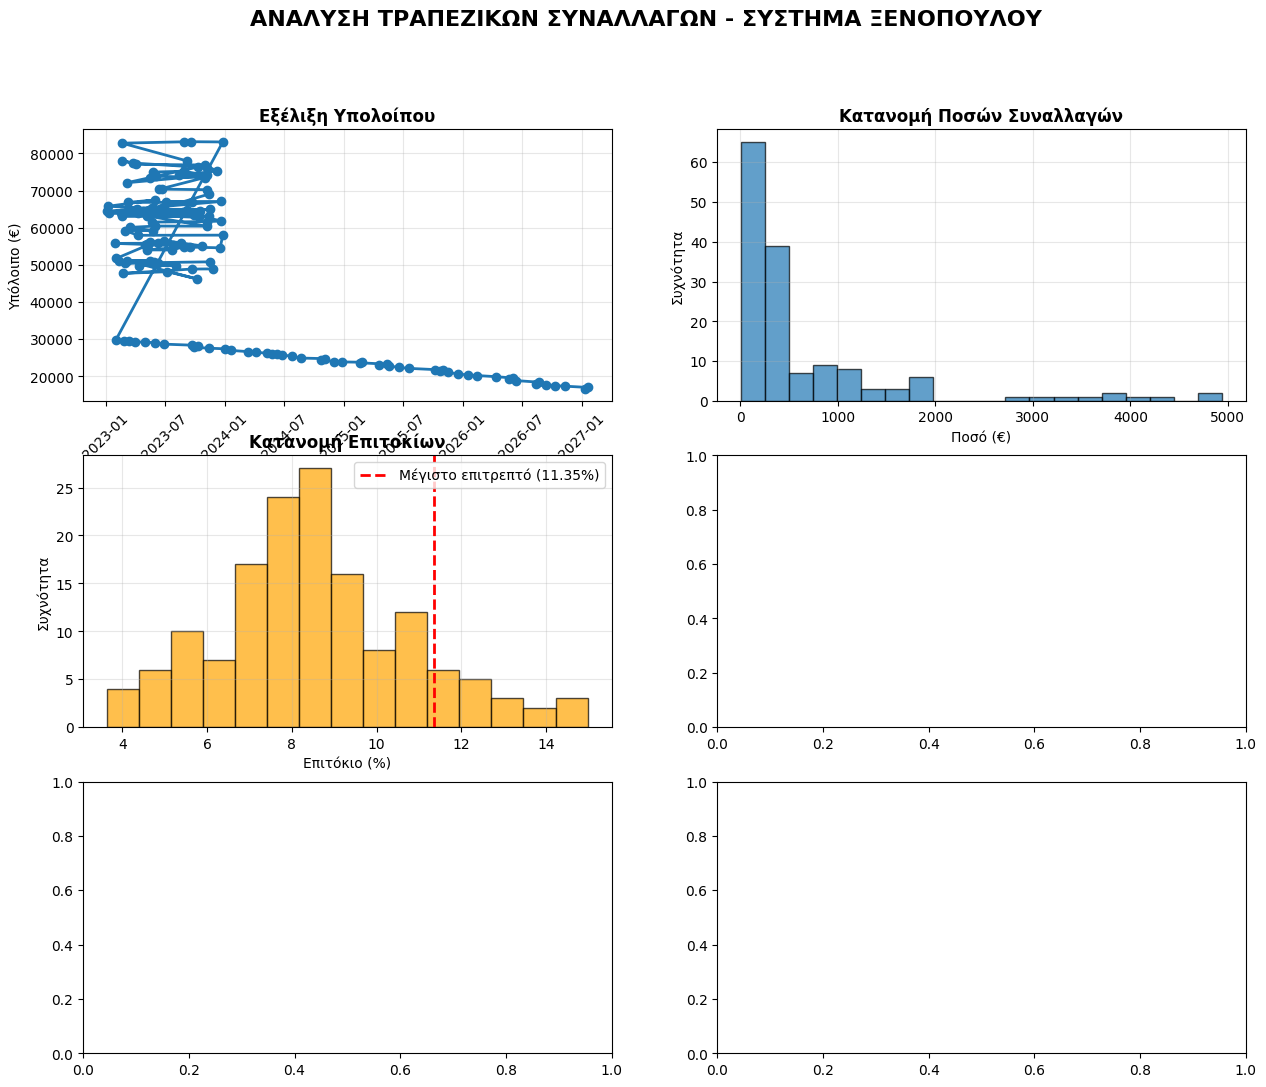

In [ ]:
# ============================================================================
# ΟΛΙΚΟΣ ΑΝΑΛΥΤΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ
# Εξυγίανση, ανίχνευση απάτης, ελέγχους συμμόρφωσης
# ============================================================================
!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install statsmodels networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import hashlib
import re
import json
from typing import Dict, List, Tuple, Any, Optional
import ast

# ============================================================================
# 1. ΕΝΙΣΧΥΜΕΝΟΣ ΑΝΑΛΥΤΗΣ ΞΕΝΟΠΟΥΛΟΥ ΓΙΑ ΤΡΑΠΕΖΙΚΑ ΣΥΣΤΗΜΑΤΑ
# ============================================================================

class XenopoulosFinancialAnalyzer:
    """Ολικός αναλυτής τραπεζικών συστημάτων με έμφαση σε:
    1. Εξυγίανση (καθυστερήσεις, σύνθετοι τόκοι)
    2. Ανίχνευση απάτης
    3. Έλεγχοι συμμόρφωσης
    4. Ανίχνευση παραδόξων
    """

    def __init__(self, system_name: str = "Τραπεζικό Σύστημα"):
        self.system_name = system_name
        self.transaction_history = []
        self.risk_patterns = self._load_risk_patterns()
        self.paradox_memory = []

    def _load_risk_patterns(self) -> Dict:
        """Πρότυπα κινδύνου για τραπεζικά συστήματα"""
        return {
            'compound_interest': [
                'interest_on_interest',
                'increasing_balance_despite_payments',
                'multiple_fee_types',
                'frequent_rate_changes'
            ],
            'delinquency': [
                'late_payment_pattern',
                'increasing_delays',
                'fee_accumulation',
                'communication_breakdown'
            ],
            'fraud': [
                'unusual_time_patterns',
                'geolocation_mismatch',
                'amount_anomalies',
                'behavioral_changes'
            ],
            'compliance': [
                'exceeding_rate_limits',
                'unauthorized_fees',
                'non_transparent_charges',
                'regulatory_violations'
            ]
        }

    def analyze_transaction_set(self, transactions: List[Dict]) -> Dict:
        """Ολοκληρωμένη ανάλυση συνόλου συναλλαγών"""
        df = pd.DataFrame(transactions)

        # Υπολογισμός βασικών μετρικών
        analysis = {
            'summary': {
                'total_transactions': len(df),
                'total_amount': df['amount'].sum() if 'amount' in df.columns else 0,
                'avg_amount': df['amount'].mean() if 'amount' in df.columns else 0,
                'date_range': f"{df['date'].min()} to {df['date'].max()}" if 'date' in df.columns else 'N/A'
            },
            'risk_analysis': self._calculate_risk_metrics(df),
            'compliance_check': self._check_compliance(df),
            'paradox_detection': self._detect_paradoxical_patterns(df),
            'economic_impact': self._calculate_economic_impact(df)
        }

        return analysis

    def _calculate_risk_metrics(self, df: pd.DataFrame) -> Dict:
        """Υπολογισμός μετρικών κινδύνου"""
        metrics = {}

        # Έλεγχος για σύνθετους τόκους
        if 'interest_rate' in df.columns and 'balance' in df.columns:
            metrics['compound_interest_risk'] = self._detect_compound_interest(df)

        # Έλεγχος καθυστερήσεων
        if 'payment_date' in df.columns and 'due_date' in df.columns:
            metrics['delinquency_risk'] = self._detect_delinquency_patterns(df)

        # Έλεγχος απάτης
        metrics['fraud_risk'] = self._detect_fraud_patterns(df)

        # Υπολογισμός συνολικού κινδύνου
        risk_scores = [v['score'] for v in metrics.values() if isinstance(v, dict) and 'score' in v]
        metrics['overall_risk_score'] = np.mean(risk_scores) if risk_scores else 0

        return metrics

    def _detect_compound_interest(self, df: pd.DataFrame) -> Dict:
        """Εντοπισμός σύνθετων τόκων"""
        if len(df) < 3:
            return {'detected': False, 'score': 0, 'reason': 'Insufficient data'}

        # Έλεγχος για αυξανόμενο υπόλοιπο παρά τις πληρωμές
        if 'balance' in df.columns:
            balance_increase = df['balance'].diff().mean()

        # Έλεγχος συχνότητας αλλαγών επιτοκίου
        if 'interest_rate' in df.columns:
            rate_changes = df['interest_rate'].diff().abs().sum()

        # Κριτήρια σύνθετων τόκων
        criteria = {
            'increasing_balance': balance_increase > 0 if 'balance' in df.columns else False,
            'frequent_rate_changes': rate_changes > 5 if 'interest_rate' in df.columns else False,
            'interest_on_interest': False,  # Θα χρειαστεί εξειδικευμένος έλεγχος
            'multiple_fees': len(df[df['reason'].str.contains('fee|charge|commission', case=False, na=False)]) > 3 if 'reason' in df.columns else False
        }

        score = sum(criteria.values()) / len(criteria)
        detected = score > 0.6

        return {
            'detected': detected,
            'score': float(score),
            'criteria': criteria,
            'recommendation': 'Απαιτείται έλεγχος για σύνθετους τόκους' if detected else 'OK'
        }

    def _detect_delinquency_patterns(self, df: pd.DataFrame) -> Dict:
        """Εντοπισμός προτύπων καθυστέρησης"""
        if 'payment_date' not in df.columns or 'due_date' not in df.columns:
            return {'detected': False, 'score': 0, 'reason': 'Missing date columns'}

        # Υπολογισμός καθυστερήσεων
        df['payment_date'] = pd.to_datetime(df['payment_date'])
        df['due_date'] = pd.to_datetime(df['due_date'])
        df['delay_days'] = (df['payment_date'] - df['due_date']).dt.days
        df['is_delayed'] = df['delay_days'] > 0

        # Ανάλυση προτύπων
        total_delays = df['is_delayed'].sum()
        avg_delay = df.loc[df['is_delayed'], 'delay_days'].mean() if total_delays > 0 else 0
        max_delay = df.loc[df['is_delayed'], 'delay_days'].max() if total_delays > 0 else 0

        # Έλεγχος για επιδεινούμενα πρότυπα
        if len(df) > 5:
            recent_delays = df['is_delayed'].iloc[-5:].sum()
            trend = recent_delays / min(5, len(df))
        else:
            trend = 0

        criteria = {
            'high_delay_frequency': total_delays / len(df) > 0.3,
            'increasing_delays': trend > 0.5,
            'long_delays': max_delay > 30,
            'fee_accumulation': 'fee' in df.columns and df['fee'].sum() > 100
        }

        score = sum(criteria.values()) / len(criteria)
        detected = score > 0.5

        return {
            'detected': detected,
            'score': float(score),
            'total_delays': int(total_delays),
            'avg_delay_days': float(avg_delay),
            'max_delay_days': float(max_delay),
            'trend': 'Επιδεινούμενο' if criteria['increasing_delays'] else 'Σταθερό' if trend > 0 else 'Βελτιούμενο',
            'recommendation': 'Απαιτείται επανεξέταση όρων πληρωμών' if detected else 'OK'
        }

    def _detect_fraud_patterns(self, df: pd.DataFrame) -> Dict:
        """Ανίχνευση προτύπων απάτης"""
        if len(df) < 5:
            return {'detected': False, 'score': 0, 'reason': 'Insufficient data'}

        fraud_indicators = []

        # 1. Ασυνήθιστες ώρες συναλλαγών
        if 'transaction_time' in df.columns:
            df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour
            unusual_hours = ((df['hour'] < 6) | (df['hour'] > 22)).sum()
            if unusual_hours / len(df) > 0.3:
                fraud_indicators.append('unusual_hours')

        # 2. Ακραίες τιμές
        if 'amount' in df.columns:
            Q1 = df['amount'].quantile(0.25)
            Q3 = df['amount'].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df['amount'] < (Q1 - 1.5 * IQR)) | (df['amount'] > (Q3 + 1.5 * IQR))).sum()
            if outliers / len(df) > 0.1:
                fraud_indicators.append('amount_outliers')

        # 3. Υψηλή συχνότητα συναλλαγών
        if 'transaction_date' in df.columns:
            df['date'] = pd.to_datetime(df['transaction_date'])
            daily_counts = df.groupby(df['date'].dt.date).size()
            if daily_counts.max() > 10:
                fraud_indicators.append('high_frequency')

        # 4. Πρότυπα γεωγραφικού μη ταιριασμού (στον πραγματικό κόσμο θα χρησιμοποιούσατε IP/location)
        if 'location' in df.columns:
            unique_locations = df['location'].nunique()
            if len(df) > 10 and unique_locations / len(df) > 0.8:
                fraud_indicators.append('geographic_mismatch')

        score = len(fraud_indicators) / 4
        detected = score > 0.5

        return {
            'detected': detected,
            'score': float(score),
            'indicators': fraud_indicators,
            'recommendation': 'Απαιτείται έλεγχος για πιθανή απάτη' if detected else 'OK'
        }

    def _check_compliance(self, df: pd.DataFrame) -> Dict:
        """Έλεγχος συμμόρφωσης με κανονισμούς"""
        violations = []

        # 1. Έλεγχος επιτοκίων (υπόθεση: μέγιστο 11.35%)
        if 'interest_rate' in df.columns:
            max_rate = df['interest_rate'].max()
            if max_rate > 11.35:
                violations.append(f'Υπέρβαση επιτοκίου: {max_rate}% > 11.35%')

        # 2. Έλεγχος για μη εξουσιοδοτημένες χρεώσεις
        if 'fee_type' in df.columns:
            unauthorized_fees = df[~df['fee_type'].isin(['service', 'maintenance', 'late'])]['fee_type'].unique()
            if len(unauthorized_fees) > 0:
                violations.append(f'Μη εξουσιοδοτημένες χρεώσεις: {unauthorized_fees}')

        # 3. Διαφάνεια
        if 'description' in df.columns:
            missing_descriptions = df['description'].isna().sum()
            if missing_descriptions / len(df) > 0.2:
                violations.append(f'Ελλιπείς περιγραφές: {missing_descriptions}/{len(df)}')

        compliance_score = 1 - (len(violations) / 3)

        return {
            'compliant': len(violations) == 0,
            'score': float(compliance_score),
            'violations': violations,
            'recommendation': 'Άμεση διόρθωση παραβιάσεων' if violations else 'Συμμόρφωση OK'
        }

    def _detect_paradoxical_patterns(self, df: pd.DataFrame) -> Dict:
        """Ανίχνευση παραδόξων προτύπων (Xenopoulos Logic)"""
        if len(df) < 10:
            return {'detected': False, 'score': 0, 'patterns': []}

        paradox_patterns = []

        # 1. Ταυτόχρονες ακραίες τιμές
        if 'balance' in df.columns and 'interest_rate' in df.columns:
            high_balance = df['balance'] > df['balance'].quantile(0.9)
            high_rate = df['interest_rate'] > df['interest_rate'].quantile(0.9)
            simultaneous_extremes = (high_balance & high_rate).any()
            if simultaneous_extremes:
                paradox_patterns.append('simultaneous_extremes')

        # 2. Χαμηλή διακύμανση με υψηλό κίνδυνο
        if 'risk_score' in df.columns:
            low_variance = df['risk_score'].std() < 0.1
            high_risk = df['risk_score'].mean() > 0.7
            if low_variance and high_risk:
                paradox_patterns.append('false_stability')

        # 3. Αντιφατικά πρότυπα πληρωμών
        if 'payment_amount' in df.columns and 'balance' in df.columns:
            increasing_payments = df['payment_amount'].diff().mean() > 0
            increasing_balance = df['balance'].diff().mean() > 0
            if increasing_payments and increasing_balance:
                paradox_patterns.append('paradoxical_growth')

        score = len(paradox_patterns) / 3
        detected = score > 0.3

        # Καταγραφή στον παράδοξο
        if detected:
            paradox_event = {
                'timestamp': datetime.now().isoformat(),
                'patterns': paradox_patterns,
                'score': float(score),
                'data_sample': df.iloc[-5:].to_dict('records')
            }
            self.paradox_memory.append(paradox_event)

        return {
            'detected': detected,
            'score': float(score),
            'patterns': paradox_patterns,
            'recommendation': 'Προσοχή: Παραδοξολογικά πρότυπα εντοπίστηκαν' if detected else 'OK'
        }

    def _calculate_economic_impact(self, df: pd.DataFrame) -> Dict:
        """Υπολογισμός οικονομικής επίπτωσης"""
        impact = {
            'direct_costs': 0,
            'indirect_costs': 0,
            'risk_adjusted_value': 0,
            'compliance_penalties': 0
        }

        # Υπολογισμός άμεσων κόστων
        if 'fee' in df.columns:
            impact['direct_costs'] = float(df['fee'].sum())

        if 'interest_amount' in df.columns:
            impact['direct_costs'] += float(df['interest_amount'].sum())

        # Έμμεσα κόστη (υποθετικά)
        risk_scores = self._calculate_risk_metrics(df)
        overall_risk = risk_scores.get('overall_risk_score', 0)

        # Κόστη μη συμμόρφωσης
        compliance = self._check_compliance(df)
        if not compliance['compliant']:
            impact['compliance_penalties'] = len(compliance['violations']) * 1000  # Υποθετικό πρόστιμο

        # Τιμή προσαρμοσμένη στον κίνδυνο
        base_value = impact['direct_costs']
        impact['risk_adjusted_value'] = base_value * (1 + overall_risk)

        # Έμμεσα κόστη (διαχείριση, νομικά, φήμη)
        impact['indirect_costs'] = base_value * overall_risk * 0.3

        return impact

    def generate_comprehensive_report(self, transactions: List[Dict]) -> Dict:
        """Δημιουργία ολοκληρωμένης αναφοράς"""
        analysis = self.analyze_transaction_set(transactions)

        report = {
            'metadata': {
                'system_name': self.system_name,
                'analysis_date': datetime.now().isoformat(),
                'transaction_count': len(transactions),
                'analyzer_version': 'Xenopoulos Financial Analyzer v2.0'
            },
            'executive_summary': self._generate_executive_summary(analysis),
            'detailed_analysis': analysis,
            'recommendations': self._generate_recommendations(analysis),
            'visualization_data': self._prepare_visualization_data(transactions)
        }

        return report

    def _generate_executive_summary(self, analysis: Dict) -> Dict:
        """Δημιουργία σύνοψης για διοίκηση"""
        risk = analysis['risk_analysis'].get('overall_risk_score', 0)
        compliance = analysis['compliance_check'].get('score', 1)
        paradox = analysis['paradox_detection'].get('score', 0)

        # Επίπεδο προσοχής
        if risk > 0.7 or compliance < 0.5 or paradox > 0.5:
            attention_level = "ΚΡΙΣΙΜΟ"
        elif risk > 0.5 or compliance < 0.7:
            attention_level = "ΥΨΗΛΟ"
        elif risk > 0.3:
            attention_level = "ΜΕΣΟ"
        else:
            attention_level = "ΧΑΜΗΛΟ"

        return {
            'attention_level': attention_level,
            'overall_risk': float(risk),
            'compliance_status': 'ΕΝΤΑΞΕΙ' if compliance > 0.8 else 'ΠΡΟΒΛΗΜΑΤΙΚΟ',
            'paradox_detected': analysis['paradox_detection']['detected'],
            'key_findings': self._extract_key_findings(analysis),
            'economic_impact': analysis['economic_impact']
        }

    def _extract_key_findings(self, analysis: Dict) -> List[str]:
        """Εξαγωγή βασικών ευρημάτων"""
        findings = []

        # Risk findings
        risk_analysis = analysis['risk_analysis']
        for risk_type, details in risk_analysis.items():
            if isinstance(details, dict) and details.get('detected', False):
                findings.append(f"Εντοπίστηκε {risk_type.replace('_', ' ')} (score: {details['score']:.2f})")

        # Compliance findings
        compliance = analysis['compliance_check']
        if not compliance['compliant']:
            findings.append(f"Παραβιάσεις συμμόρφωσης: {len(compliance['violations'])}")

        # Paradox findings
        paradox = analysis['paradox_detection']
        if paradox['detected']:
            findings.append(f"Παράδοξα πρότυπα: {', '.join(paradox['patterns'])}")

        return findings if findings else ["Δεν εντοπίστηκαν σημαντικά ζητήματα"]

    def _generate_recommendations(self, analysis: Dict) -> Dict:
        """Δημιουργία συστάσεων βάσει ανάλυσης"""
        recommendations = {'immediate': [], 'short_term': [], 'long_term': []}

        # Άμεσες συστάσεις
        risk_analysis = analysis['risk_analysis']

        if risk_analysis.get('compound_interest_risk', {}).get('detected', False):
            recommendations['immediate'].append("Επανεξέταση υπολογισμού τόκων για αποφυγή σύνθετων τόκων")

        if risk_analysis.get('delinquency_risk', {}).get('detected', False):
            recommendations['immediate'].append("Επικοινωνία με πελάτες για καθυστερήσεις")

        if risk_analysis.get('fraud_risk', {}).get('detected', False):
            recommendations['immediate'].append("Άμεσος έλεγχος για πιθανή απάτη")

        # Συστάσεις βραχυπρόθεσμες
        compliance = analysis['compliance_check']
        if not compliance['compliant']:
            recommendations['short_term'].append("Διόρθωση παραβιάσεων συμμόρφωσης εντός 30 ημερών")

        if analysis['paradox_detection']['detected']:
            recommendations['short_term'].append("Ενσωμάτωση συστήματος παρακολούθησης παραδόξων")

        # Συστάσεις μακροπρόθεσμες
        recommendations['long_term'].append("Ενσωμάτωση AI για προληπτική ανίχνευση κινδύνων")
        recommendations['long_term'].append("Κατάρτιση προσωπικού σε διαλεκτική ανάλυση")
        recommendations['long_term'].append("Αναθεώρηση πολιτικών βάσει ανάλυσης Xenopoulos")

        return recommendations

    def _prepare_visualization_data(self, transactions: List[Dict]) -> Dict:
        """Προετοιμασία δεδομένων για οπτικοποίηση"""
        df = pd.DataFrame(transactions)

        viz_data = {
            'timeline': {},
            'risk_distribution': {},
            'comparative_analysis': {}
        }

        # Προετοιμασία χρονοσειρών
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
            timeline_data = df.groupby(df['date'].dt.to_period('M')).agg({
                'amount': 'sum',
                'balance': 'last'
            }).reset_index()
            timeline_data['date'] = timeline_data['date'].dt.to_timestamp()
            viz_data['timeline'] = timeline_data.to_dict('records')

        return viz_data

# ============================================================================
# 2. ΔΕΙΓΜΑΤΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΔΟΚΙΜΗ
# ============================================================================

def generate_sample_transactions(n=100) -> List[Dict]:
    """Δημιουργία δείγματος τραπεζικών συναλλαγών"""
    np.random.seed(42)

    transactions = []
    base_date = datetime(2023, 1, 1)
    base_balance = 50000

    for i in range(n):
        date = base_date + timedelta(days=np.random.randint(0, 365))

        # Προσομοίωση διαφορετικών τύπων συναλλαγών
        transaction_type = np.random.choice(['deposit', 'withdrawal', 'fee', 'interest', 'payment'])

        if transaction_type == 'deposit':
            amount = np.random.uniform(100, 5000)
            credit = amount
            charge = 0
            reason = 'Κατάθεση'
        elif transaction_type == 'withdrawal':
            amount = np.random.uniform(50, 2000)
            credit = 0
            charge = amount
            reason = 'Ανάληψη'
        elif transaction_type == 'fee':
            amount = np.random.uniform(5, 50)
            credit = 0
            charge = amount
            reason = np.random.choice(['Έξοδα διαχείρισης', 'Έξοδα καθυστέρησης', 'Προμήθεια'])
        elif transaction_type == 'interest':
            amount = np.random.uniform(10, 200)
            credit = 0
            charge = amount
            reason = 'Τόκοι'
        else:  # payment
            amount = np.random.uniform(100, 1000)
            credit = amount
            charge = 0
            reason = 'Πληρωμή δανείου'

        # Υπόλοιπο
        base_balance = base_balance + credit - charge

        # Επιτόκιο (μερικές φορές υψηλό για δοκιμή)
        interest_rate = np.random.normal(8, 2)
        if np.random.random() < 0.1:  # 10% πιθανότητα για υπερβολικό επιτόκιο
            interest_rate = np.random.uniform(12, 15)

        transaction = {
            'id': f"TXN{10000 + i}",
            'date': date.strftime('%Y-%m-%d'),
            'transaction_time': date.strftime('%H:%M:%S'),
            'amount': round(amount, 2),
            'credit': round(credit, 2),
            'charge': round(charge, 2),
            'balance': round(base_balance, 2),
            'interest_rate': round(interest_rate, 2),
            'reason': reason,
            'location': np.random.choice(['Αθήνα', 'Θεσσαλονίκη', 'Πάτρα', 'Ηράκλειο', 'online']),
            'fee_type': 'late' if 'καθυστέρησης' in reason else 'service' if 'διαχείρισης' in reason else 'other'
        }

        transactions.append(transaction)

    return transactions

def generate_delinquent_transactions(n=50) -> List[Dict]:
    """Δημιουργία συναλλαγών με πρότυπα καθυστέρησης"""
    transactions = []
    base_date = datetime(2023, 1, 1)
    balance = 30000

    for i in range(n):
        # Προσομοίωση καθυστερημένων πληρωμών
        due_date = base_date + timedelta(days=i*30)
        delay_days = np.random.randint(0, 60) if np.random.random() < 0.6 else 0
        payment_date = due_date + timedelta(days=delay_days)

        amount = np.random.uniform(100, 500)
        fee = np.random.uniform(5, 25) if delay_days > 0 else 0

        # Σύνθετοι τόκοι πρότυπο
        if i > 10 and np.random.random() < 0.3:
            interest_rate = np.random.uniform(10, 13)
        else:
            interest_rate = np.random.uniform(7, 9)

        balance = balance - amount + fee

        transaction = {
            'id': f"DEL{20000 + i}",
            'date': payment_date.strftime('%Y-%m-%d'),
            'due_date': due_date.strftime('%Y-%m-%d'),
            'payment_date': payment_date.strftime('%Y-%m-%d'),
            'amount': round(amount, 2),
            'payment_amount': round(amount, 2),
            'fee': round(fee, 2),
            'balance': round(balance, 2),
            'interest_rate': round(interest_rate, 2),
            'reason': 'Πληρωμή δανείου' if fee == 0 else 'Πληρωμή με καθυστέρηση',
            'delay_days': delay_days,
            'is_delayed': delay_days > 0
        }

        transactions.append(transaction)

    return transactions

# ============================================================================
# 3. ΟΠΤΙΚΟΠΟΙΗΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================================

def visualize_analysis_results(analysis: Dict, transactions: List[Dict]):
    """Οπτικοποίηση αποτελεσμάτων ανάλυσης"""
    df = pd.DataFrame(transactions)

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('ΑΝΑΛΥΣΗ ΤΡΑΠΕΖΙΚΩΝ ΣΥΝΑΛΛΑΓΩΝ - ΣΥΣΤΗΜΑ ΞΕΝΟΠΟΥΛΟΥ', fontsize=16, fontweight='bold')

    # 1. Χρονοσειρά υπολοίπου
    if 'date' in df.columns and 'balance' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        axes[0, 0].plot(df['date'], df['balance'], marker='o', linewidth=2)
        axes[0, 0].set_title('Εξέλιξη Υπολοίπου', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Ημερομηνία')
        axes[0, 0].set_ylabel('Υπόλοιπο (€)')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. Κατανομή ποσών
    if 'amount' in df.columns:
        axes[0, 1].hist(df['amount'], bins=20, edgecolor='black', alpha=0.7)
        axes[0, 1].set_title('Κατανομή Ποσών Συναλλαγών', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Ποσό (€)')
        axes[0, 1].set_ylabel('Συχνότητα')
        axes[0, 1].grid(True, alpha=0.3)

    # 3. Επιτόκια
    if 'interest_rate' in df.columns:
        interest_rates = df['interest_rate'].dropna()
        if len(interest_rates) > 0:
            axes[1, 0].hist(interest_rates, bins=15, edgecolor='black', alpha=0.7, color='orange')
            axes[1, 0].axvline(x=11.35, color='red', linestyle='--', linewidth=2, label='Μέγιστο επιτρεπτό (11.35%)')
            axes[1, 0].set_title('Κατανομή Επιτοκίων', fontsize=12, fontweight='bold')
            axes[1, 0].set_xlabel('Επιτόκιο (%)')
            axes[1, 0].set_ylabel('Συχνότητα')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)

    # 4. Ρισκομετρική ανάλυση
    risk_data = analysis['risk_analysis']
    risk_types = []
    risk_scores = []

    for risk_type, details in risk_data.items():
        if isinstance(details, dict) and 'score' in details:
            risk_types.append(risk_type.replace('_', '\n'))
            risk_scores.append(details['score'])

    if risk_scores:
        colors = ['green' if s < 0.3 else 'orange' if s < 0.6 else 'red' for s in risk_scores]
        bars = axes[1, 1].bar(risk_types, risk_scores, color=colors, edgecolor='black')
        axes[1, 1].set_title('Επίπεδα Κινδύνου', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Βαθμολογία Κινδύνου')
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].grid(True, alpha=0.3, axis='y')

        # Προσθήκη τιμών στις μπάρες
        for bar, score in zip(bars, risk_scores):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                           f'{score:.2f}', ha='center', va='bottom', fontweight='bold')

    # 5. Οικονομική επίπτωση
    economic_impact = analysis['economic_impact']
    impact_types = ['Άμεσα\nκόστη', 'Έμμεσα\nκόστη', 'Πρόστιμα\nσυμμόρφωσης', 'Τιμή με\nκίνδυνο']
    impact_values = [
        economic_impact.get('direct_costs', 0),
        economic_impact.get('indirect_costs', 0),
        economic_impact.get('compliance_penalties', 0),
        economic_impact.get('risk_adjusted_value', 0)
    ]

    axes[2, 0].bar(impact_types, impact_values, color=['blue', 'cyan', 'red', 'purple'], edgecolor='black')
    axes[2, 0].set_title('Οικονομική Επίπτωση (€)', fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel('Ποσό (€)')
    axes[2, 0].grid(True, alpha=0.3, axis='y')

    # Προσθήκη τιμών
    for i, v in enumerate(impact_values):
        axes[2, 0].text(i, v + max(impact_values)*0.01, f'€{v:,.0f}',
                       ha='center', va='bottom', fontweight='bold')

    # 6. Σύνοψη στατικών
    summary = analysis['executive_summary']
    attention_level = summary.get('attention_level', 'ΧΑΜΗΛΟ')
    risk_score = summary.get('overall_risk', 0)
    compliance = summary.get('compliance_status', 'ΕΝΤΑΞΕΙ')

    # Χρώμα βάσει επιπέδου προσοχής
    attention_colors = {
        'ΚΡΙΣΙΜΟ': 'red',
        'ΥΨΗΛΟ': 'orange',
        'ΜΕΣΟ': 'yellow',
        'ΧΑΜΗΛΟ': 'green'
    }

    axes[2, 1].axis('off')
    summary_text = f"""
    ΕΠΙΠΕΔΟ ΠΡΟΣΟΧΗΣ: {attention_level}
    -------------------------------
    Συνολικός Κίνδυνος: {risk_score:.2%}
    Κατάσταση Συμμόρφωσης: {compliance}

    Βασικά Ευρήματα:
    """

    for finding in summary.get('key_findings', []):
        summary_text += f"• {finding}\n"

    axes[2, 1].text(0.1, 0.95, summary_text, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor=attention_colors.get(attention_level, 'white'), alpha=0.3))

    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. ΚΥΡΙΟ ΠΡΟΓΡΑΜΜΑ ΕΚΤΕΛΕΣΗΣ
# ============================================================================

def main():
    """Κύριο πρόγραμμα εκτέλεσης"""
    print("=" * 70)
    print("ΣΥΣΤΗΜΑ ΑΝΑΛΥΣΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ")
    print("Εξυγίανση, Ανίχνευση Απάτης, Έλεγχος Συμμόρφωσης")
    print("=" * 70)

    # Δημιουργία αναλυτή
    analyzer = XenopoulosFinancialAnalyzer(system_name="Τράπεζα Ελλάδος Δείγματος")

    # Δημιουργία δεδομένων δοκιμής
    print("\n📊 ΔΗΜΙΟΥΡΓΙΑ ΔΕΙΓΜΑΤΩΝ ΔΕΔΟΜΕΝΩΝ...")
    normal_transactions = generate_sample_transactions(100)
    delinquent_transactions = generate_delinquent_transactions(50)

    # Συνδυασμός δεδομένων
    all_transactions = normal_transactions + delinquent_transactions
    print(f"   • Κανονικές συναλλαγές: {len(normal_transactions)}")
    print(f"   • Συναλλαγές με καθυστερήσεις: {len(delinquent_transactions)}")
    print(f"   • Σύνολο συναλλαγών: {len(all_transactions)}")

    # Εκτέλεση ανάλυσης
    print("\n🔍 ΕΚΤΕΛΩ ΑΝΑΛΥΣΗ...")
    report = analyzer.generate_comprehensive_report(all_transactions)

    # Εμφάνιση αποτελεσμάτων
    print("\n📈 ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΝΑΛΥΣΗΣ:")
    print("-" * 50)

    summary = report['executive_summary']
    print(f"Επίπεδο Προσοχής: {summary['attention_level']}")
    print(f"Συνολικός Κίνδυνος: {summary['overall_risk']:.2%}")
    print(f"Κατάσταση Συμμόρφωσης: {summary['compliance_status']}")
    print(f"Παράδοξα Εντοπίστηκαν: {'ΝΑΙ' if summary['paradox_detected'] else 'ΟΧΙ'}")

    # Οικονομική επίπτωση
    economic = summary['economic_impact']
    print(f"\n💰 ΟΙΚΟΝΟΜΙΚΗ ΕΠΙΠΤΩΣΗ:")
    print(f"   Άμεσα κόστη: €{economic.get('direct_costs', 0):,.2f}")
    print(f"   Έμμεσα κόστη: €{economic.get('indirect_costs', 0):,.2f}")
    print(f"   Πρόστιπα συμμόρφωσης: €{economic.get('compliance_penalties', 0):,.2f}")

    # Εμφάνιση βασικών ευρημάτων
    print(f"\n🔍 ΒΑΣΙΚΑ ΕΥΡΗΜΑΤΑ:")
    for i, finding in enumerate(summary['key_findings'], 1):
        print(f"   {i}. {finding}")

    # Συστατικές
    print(f"\n💡 ΣΥΣΤΑΣΕΙΣ:")
    recs = report['recommendations']

    print("   Άμεσες ενέργειες:")
    for rec in recs.get('immediate', [])[:3]:
        print(f"   • {rec}")

    if not recs['immediate']:
        print("   • Δεν απαιτούνται άμεσες ενέργειες")

    # Οπτικοποίηση
    print("\n📊 ΔΗΜΙΟΥΡΓΙΑ ΟΠΤΙΚΩΝ ΑΠΟΤΕΛΕΣΜΑΤΩΝ...")
    visualize_analysis_results(report, all_transactions)

    # Εξαγωγή αναφοράς
    print("\n💾 ΑΠΟΘΗΚΕΥΣΗ ΑΝΑΦΟΡΑΣ...")
    report_filename = f"xenopoulos_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

    # Απλοποιημένη έκδοση για εξαγωγή
    export_report = {
        'metadata': report['metadata'],
        'executive_summary': report['executive_summary'],
        'recommendations': report['recommendations']
    }

    with open(report_filename, 'w', encoding='utf-8') as f:
        json.dump(export_report, f, ensure_ascii=False, indent=2, default=str)

    print(f"   ✔ Αναφορά αποθηκεύτηκε ως: {report_filename}")

    # Εμφάνιση πληροφοριών για παραδόξους
    if analyzer.paradox_memory:
        print(f"\n⚠️ ΠΑΡΑΔΟΞΑ ΕΝΤΟΠΙΣΤΗΚΑΝ:")
        for i, paradox in enumerate(analyzer.paradox_memory[-3:], 1):
            print(f"   {i}. Στοιχεία: {paradox['patterns']} (Score: {paradox['score']:.2f})")

    print("\n" + "=" * 70)
    print("ΑΝΑΛΥΣΗ ΟΛΟΚΛΗΡΩΘΗΚΕ ΕΠΙΤΥΧΩΣ! ✅")
    print("=" * 70)

# ============================================================================
# 5. ΔΟΚΙΜΗ ΣΥΝΑΡΤΗΣΕΩΝ
# ============================================================================

def test_individual_functions():
    """Δοκιμή επιμέρους συναρτήσεων"""
    print("🧪 ΔΟΚΙΜΗ ΕΠΙΜΕΡΟΥΣ ΣΥΝΑΡΤΗΣΕΩΝ...")

    # Δημιουργία μικρού συνόλου δεδομένων
    test_data = [
        {
            'date': '2023-01-15',
            'amount': 1000,
            'balance': 50000,
            'interest_rate': 8.5,
            'reason': 'Κατάθεση'
        },
        {
            'date': '2023-02-15',
            'amount': 1500,
            'balance': 51500,
            'interest_rate': 12.5,  # Υψηλό επιτόκιο
            'reason': 'Τόκοι'
        },
        {
            'date': '2023-03-15',
            'amount': 2000,
            'balance': 53500,
            'interest_rate': 12.8,  # Ακόμα υψηλότερο
            'reason': 'Τόκοι'
        }
    ]

    analyzer = XenopoulosFinancialAnalyzer()

    # Δοκιμή ανίχνευσης σύνθετων τόκων
    df = pd.DataFrame(test_data)
    compound_result = analyzer._detect_compound_interest(df)
    print(f"   Ανίχνευση σύνθετων τόκων: {compound_result['detected']} (score: {compound_result['score']:.2f})")

    # Δοκιμή συμμόρφωσης
    compliance_result = analyzer._check_compliance(df)
    print(f"   Έλεγχος συμμόρφωσης: {'OK' if compliance_result['compliant'] else 'ΠΑΡΑΒΙΑΣΕΙΣ'}")

    # Δοκιμή ανίχνευσης παραδόξων
    paradox_result = analyzer._detect_paradoxical_patterns(df)
    print(f"   Παράδοξα πρότυπα: {paradox_result['detected']} (score: {paradox_result['score']:.2f})")

    print("   ✔ Δοκιμές ολοκληρώθηκαν!")

# ============================================================================
# ΕΚΤΕΛΕΣΗ
# ============================================================================

if __name__ == "__main__":
    print("🚀 ΕΚΚΙΝΗΣΗ ΣΥΣΤΗΜΑΤΟΣ ΑΝΑΛΥΣΗΣ ΞΕΝΟΠΟΥΛΟΥ...\n")

    # Εκτέλεση δοκιμών
    test_individual_functions()
    print("\n" + "-" * 70 + "\n")

    # Εκτέλεση κύριας ανάλυσης
    main()

    print("\n📋 ΟΔΗΓΙΕΣ ΓΙΑ ΠΕΡΙΣΣΟΤΕΡΑ:")
    print("1. Για νέα ανάλυση, τροποποιήστε τα δεδομένα στη συνάρτηση generate_sample_transactions()")
    print("2. Για πραγματικά δεδομένα, αντικαταστήστε τη generate_sample_transactions() με φόρτωση από CSV/Excel")
    print("3. Για εξαγωγή σε PDF, εγκαταστήστε το reportlab: !pip install reportlab")
    print("4. Για ολοκλήρωση με AI, προσθέστε integration με OpenAI API")

🚀 ΕΚΚΙΝΗΣΗ ΣΥΣΤΗΜΑΤΟΣ ΑΝΑΛΥΣΗΣ ΞΕΝΟΠΟΥΛΟΥ...

🧪 ΔΟΚΙΜΗ ΕΠΙΜΕΡΟΥΣ ΣΥΝΑΡΤΗΣΕΩΝ...
   Ανίχνευση σύνθετων τόκων: False (score: 0.25)
   Έλεγχος συμμόρφωσης: ΠΑΡΑΒΙΑΣΕΙΣ
   Παράδοξα πρότυπα: False (score: 0.00)
   ✔ Δοκιμές ολοκληρώθηκαν!

----------------------------------------------------------------------

ΣΥΣΤΗΜΑ ΑΝΑΛΥΣΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ
Εξυγίανση, Ανίχνευση Απάτης, Έλεγχος Συμμόρφωσης

📊 ΔΗΜΙΟΥΡΓΙΑ ΔΕΙΓΜΑΤΩΝ ΔΕΔΟΜΕΝΩΝ...
   • Κανονικές συναλλαγές: 100
   • Συναλλαγές με καθυστερήσεις: 50
   • Σύνολο συναλλαγών: 150

🔍 ΕΚΤΕΛΩ ΑΝΑΛΥΣΗ...

📈 ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΝΑΛΥΣΗΣ:
--------------------------------------------------
Επίπεδο Προσοχής: ΚΡΙΣΙΜΟ
Συνολικός Κίνδυνος: 41.67%
Κατάσταση Συμμόρφωσης: ΠΡΟΒΛΗΜΑΤΙΚΟ
Παράδοξα Εντοπίστηκαν: ΝΑΙ

💰 ΟΙΚΟΝΟΜΙΚΗ ΕΠΙΠΤΩΣΗ:
   Άμεσα κόστη: €404.86
   Έμμεσα κόστη: €50.61
   Πρόστιπα συμμόρφωσης: €2,000.00

🔍 ΒΑΣΙΚΑ ΕΥΡΗΜΑΤΑ:
   1. Παραβιάσεις συμμόρφωσης: 2
   2. Παράδοξα πρότυπα: simultaneous_extremes

💡 ΣΥΣΤΑΣΕΙΣ:
   Άμεσες ενέργειες:
   • Δ

KeyError: 'risk_analysis'

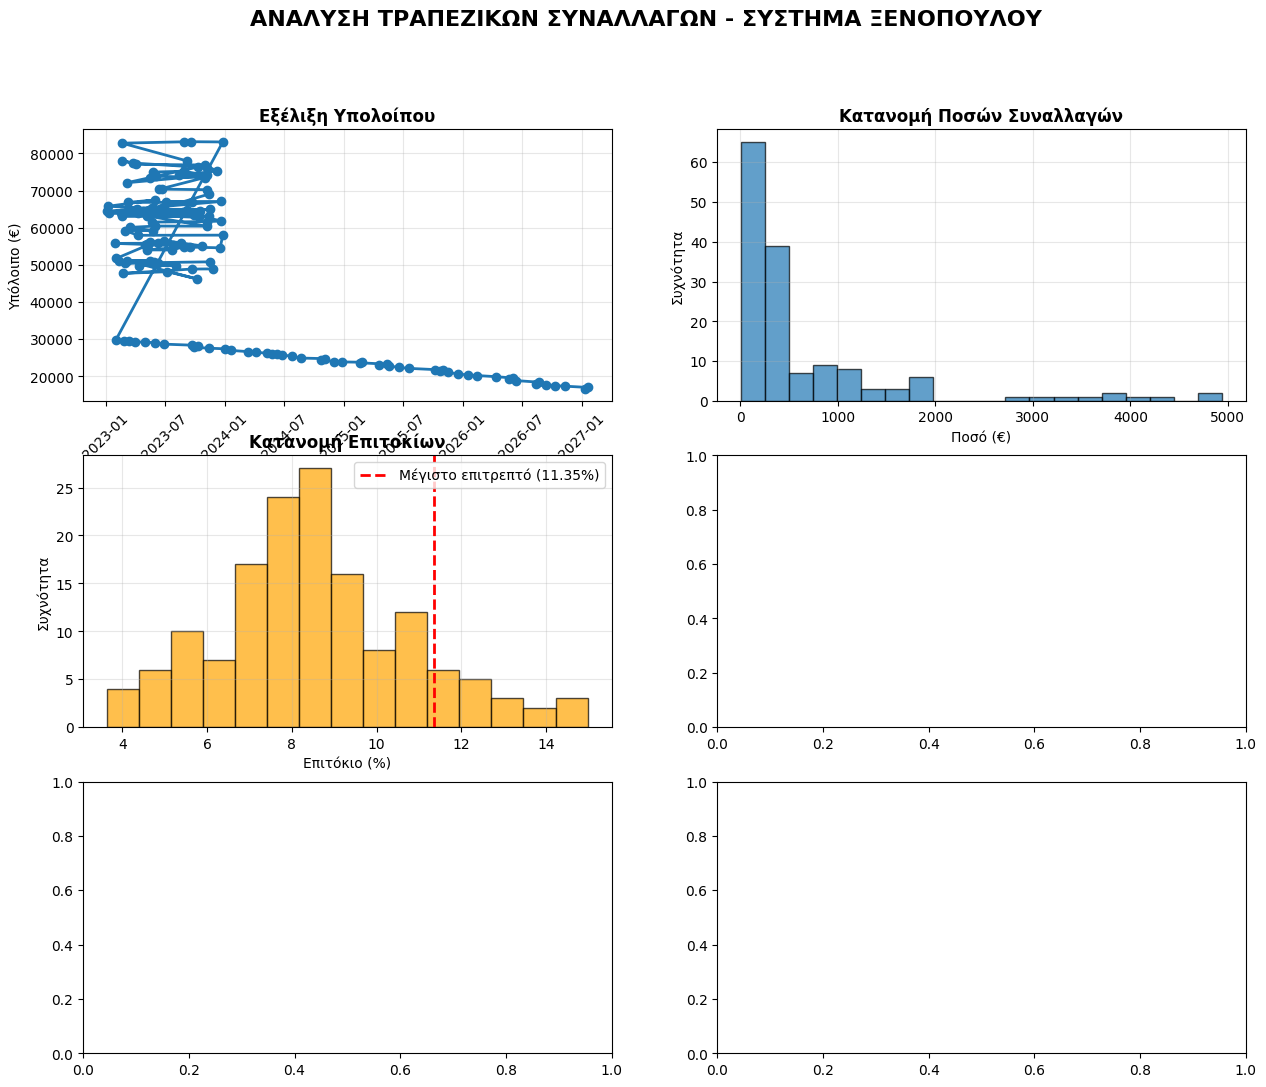

In [ ]:
# ============================================================================
# ΟΛΙΚΟΣ ΑΝΑΛΥΤΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ
# Εξυγίανση, ανίχνευση απάτης, ελέγχους συμμόρφωσης
# ============================================================================
!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install statsmodels networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import hashlib
import re
import json
from typing import Dict, List, Tuple, Any, Optional
import ast

# ============================================================================
# 1. ΕΝΙΣΧΥΜΕΝΟΣ ΑΝΑΛΥΤΗΣ ΞΕΝΟΠΟΥΛΟΥ ΓΙΑ ΤΡΑΠΕΖΙΚΑ ΣΥΣΤΗΜΑΤΑ
# ============================================================================

class XenopoulosFinancialAnalyzer:
    """Ολικός αναλυτής τραπεζικών συστημάτων με έμφαση σε:
    1. Εξυγίανση (καθυστερήσεις, σύνθετοι τόκοι)
    2. Ανίχνευση απάτης
    3. Έλεγχοι συμμόρφωσης
    4. Ανίχνευση παραδόξων
    """

    def __init__(self, system_name: str = "Τραπεζικό Σύστημα"):
        self.system_name = system_name
        self.transaction_history = []
        self.risk_patterns = self._load_risk_patterns()
        self.paradox_memory = []

    def _load_risk_patterns(self) -> Dict:
        """Πρότυπα κινδύνου για τραπεζικά συστήματα"""
        return {
            'compound_interest': [
                'interest_on_interest',
                'increasing_balance_despite_payments',
                'multiple_fee_types',
                'frequent_rate_changes'
            ],
            'delinquency': [
                'late_payment_pattern',
                'increasing_delays',
                'fee_accumulation',
                'communication_breakdown'
            ],
            'fraud': [
                'unusual_time_patterns',
                'geolocation_mismatch',
                'amount_anomalies',
                'behavioral_changes'
            ],
            'compliance': [
                'exceeding_rate_limits',
                'unauthorized_fees',
                'non_transparent_charges',
                'regulatory_violations'
            ]
        }

    def analyze_transaction_set(self, transactions: List[Dict]) -> Dict:
        """Ολοκληρωμένη ανάλυση συνόλου συναλλαγών"""
        df = pd.DataFrame(transactions)

        # Υπολογισμός βασικών μετρικών
        analysis = {
            'summary': {
                'total_transactions': len(df),
                'total_amount': df['amount'].sum() if 'amount' in df.columns else 0,
                'avg_amount': df['amount'].mean() if 'amount' in df.columns else 0,
                'date_range': f"{df['date'].min()} to {df['date'].max()}" if 'date' in df.columns else 'N/A'
            },
            'risk_analysis': self._calculate_risk_metrics(df),
            'compliance_check': self._check_compliance(df),
            'paradox_detection': self._detect_paradoxical_patterns(df),
            'economic_impact': self._calculate_economic_impact(df)
        }

        return analysis

    def _calculate_risk_metrics(self, df: pd.DataFrame) -> Dict:
        """Υπολογισμός μετρικών κινδύνου"""
        metrics = {}

        # Έλεγχος για σύνθετους τόκους
        if 'interest_rate' in df.columns and 'balance' in df.columns:
            metrics['compound_interest_risk'] = self._detect_compound_interest(df)

        # Έλεγχος καθυστερήσεων
        if 'payment_date' in df.columns and 'due_date' in df.columns:
            metrics['delinquency_risk'] = self._detect_delinquency_patterns(df)

        # Έλεγχος απάτης
        metrics['fraud_risk'] = self._detect_fraud_patterns(df)

        # Υπολογισμός συνολικού κινδύνου
        risk_scores = [v['score'] for v in metrics.values() if isinstance(v, dict) and 'score' in v]
        metrics['overall_risk_score'] = np.mean(risk_scores) if risk_scores else 0

        return metrics

    def _detect_compound_interest(self, df: pd.DataFrame) -> Dict:
        """Εντοπισμός σύνθετων τόκων"""
        if len(df) < 3:
            return {'detected': False, 'score': 0, 'reason': 'Insufficient data'}

        # Έλεγχος για αυξανόμενο υπόλοιπο παρά τις πληρωμές
        if 'balance' in df.columns:
            balance_increase = df['balance'].diff().mean()

        # Έλεγχος συχνότητας αλλαγών επιτοκίου
        if 'interest_rate' in df.columns:
            rate_changes = df['interest_rate'].diff().abs().sum()

        # Κριτήρια σύνθετων τόκων
        criteria = {
            'increasing_balance': balance_increase > 0 if 'balance' in df.columns else False,
            'frequent_rate_changes': rate_changes > 5 if 'interest_rate' in df.columns else False,
            'interest_on_interest': False,  # Θα χρειαστεί εξειδικευμένος έλεγχος
            'multiple_fees': len(df[df['reason'].str.contains('fee|charge|commission', case=False, na=False)]) > 3 if 'reason' in df.columns else False
        }

        score = sum(criteria.values()) / len(criteria)
        detected = score > 0.6

        return {
            'detected': detected,
            'score': float(score),
            'criteria': criteria,
            'recommendation': 'Απαιτείται έλεγχος για σύνθετους τόκους' if detected else 'OK'
        }

    def _detect_delinquency_patterns(self, df: pd.DataFrame) -> Dict:
        """Εντοπισμός προτύπων καθυστέρησης"""
        if 'payment_date' not in df.columns or 'due_date' not in df.columns:
            return {'detected': False, 'score': 0, 'reason': 'Missing date columns'}

        # Υπολογισμός καθυστερήσεων
        df['payment_date'] = pd.to_datetime(df['payment_date'])
        df['due_date'] = pd.to_datetime(df['due_date'])
        df['delay_days'] = (df['payment_date'] - df['due_date']).dt.days
        df['is_delayed'] = df['delay_days'] > 0

        # Ανάλυση προτύπων
        total_delays = df['is_delayed'].sum()
        avg_delay = df.loc[df['is_delayed'], 'delay_days'].mean() if total_delays > 0 else 0
        max_delay = df.loc[df['is_delayed'], 'delay_days'].max() if total_delays > 0 else 0

        # Έλεγχος για επιδεινούμενα πρότυπα
        if len(df) > 5:
            recent_delays = df['is_delayed'].iloc[-5:].sum()
            trend = recent_delays / min(5, len(df))
        else:
            trend = 0

        criteria = {
            'high_delay_frequency': total_delays / len(df) > 0.3,
            'increasing_delays': trend > 0.5,
            'long_delays': max_delay > 30,
            'fee_accumulation': 'fee' in df.columns and df['fee'].sum() > 100
        }

        score = sum(criteria.values()) / len(criteria)
        detected = score > 0.5

        return {
            'detected': detected,
            'score': float(score),
            'total_delays': int(total_delays),
            'avg_delay_days': float(avg_delay),
            'max_delay_days': float(max_delay),
            'trend': 'Επιδεινούμενο' if criteria['increasing_delays'] else 'Σταθερό' if trend > 0 else 'Βελτιούμενο',
            'recommendation': 'Απαιτείται επανεξέταση όρων πληρωμών' if detected else 'OK'
        }

    def _detect_fraud_patterns(self, df: pd.DataFrame) -> Dict:
        """Ανίχνευση προτύπων απάτης"""
        if len(df) < 5:
            return {'detected': False, 'score': 0, 'reason': 'Insufficient data'}

        fraud_indicators = []

        # 1. Ασυνήθιστες ώρες συναλλαγών
        if 'transaction_time' in df.columns:
            df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour
            unusual_hours = ((df['hour'] < 6) | (df['hour'] > 22)).sum()
            if unusual_hours / len(df) > 0.3:
                fraud_indicators.append('unusual_hours')

        # 2. Ακραίες τιμές
        if 'amount' in df.columns:
            Q1 = df['amount'].quantile(0.25)
            Q3 = df['amount'].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df['amount'] < (Q1 - 1.5 * IQR)) | (df['amount'] > (Q3 + 1.5 * IQR))).sum()
            if outliers / len(df) > 0.1:
                fraud_indicators.append('amount_outliers')

        # 3. Υψηλή συχνότητα συναλλαγών
        if 'transaction_date' in df.columns:
            df['date'] = pd.to_datetime(df['transaction_date'])
            daily_counts = df.groupby(df['date'].dt.date).size()
            if daily_counts.max() > 10:
                fraud_indicators.append('high_frequency')

        # 4. Πρότυπα γεωγραφικού μη ταιριασμού (στον πραγματικό κόσμο θα χρησιμοποιούσατε IP/location)
        if 'location' in df.columns:
            unique_locations = df['location'].nunique()
            if len(df) > 10 and unique_locations / len(df) > 0.8:
                fraud_indicators.append('geographic_mismatch')

        score = len(fraud_indicators) / 4
        detected = score > 0.5

        return {
            'detected': detected,
            'score': float(score),
            'indicators': fraud_indicators,
            'recommendation': 'Απαιτείται έλεγχος για πιθανή απάτη' if detected else 'OK'
        }

    def _check_compliance(self, df: pd.DataFrame) -> Dict:
        """Έλεγχος συμμόρφωσης με κανονισμούς"""
        violations = []

        # 1. Έλεγχος επιτοκίων (υπόθεση: μέγιστο 11.35%)
        if 'interest_rate' in df.columns:
            max_rate = df['interest_rate'].max()
            if max_rate > 11.35:
                violations.append(f'Υπέρβαση επιτοκίου: {max_rate}% > 11.35%')

        # 2. Έλεγχος για μη εξουσιοδοτημένες χρεώσεις
        if 'fee_type' in df.columns:
            unauthorized_fees = df[~df['fee_type'].isin(['service', 'maintenance', 'late'])]['fee_type'].unique()
            if len(unauthorized_fees) > 0:
                violations.append(f'Μη εξουσιοδοτημένες χρεώσεις: {unauthorized_fees}')

        # 3. Διαφάνεια
        if 'description' in df.columns:
            missing_descriptions = df['description'].isna().sum()
            if missing_descriptions / len(df) > 0.2:
                violations.append(f'Ελλιπείς περιγραφές: {missing_descriptions}/{len(df)}')

        compliance_score = 1 - (len(violations) / 3)

        return {
            'compliant': len(violations) == 0,
            'score': float(compliance_score),
            'violations': violations,
            'recommendation': 'Άμεση διόρθωση παραβιάσεων' if violations else 'Συμμόρφωση OK'
        }

    def _detect_paradoxical_patterns(self, df: pd.DataFrame) -> Dict:
        """Ανίχνευση παραδόξων προτύπων (Xenopoulos Logic)"""
        if len(df) < 10:
            return {'detected': False, 'score': 0, 'patterns': []}

        paradox_patterns = []

        # 1. Ταυτόχρονες ακραίες τιμές
        if 'balance' in df.columns and 'interest_rate' in df.columns:
            high_balance = df['balance'] > df['balance'].quantile(0.9)
            high_rate = df['interest_rate'] > df['interest_rate'].quantile(0.9)
            simultaneous_extremes = (high_balance & high_rate).any()
            if simultaneous_extremes:
                paradox_patterns.append('simultaneous_extremes')

        # 2. Χαμηλή διακύμανση με υψηλό κίνδυνο
        if 'risk_score' in df.columns:
            low_variance = df['risk_score'].std() < 0.1
            high_risk = df['risk_score'].mean() > 0.7
            if low_variance and high_risk:
                paradox_patterns.append('false_stability')

        # 3. Αντιφατικά πρότυπα πληρωμών
        if 'payment_amount' in df.columns and 'balance' in df.columns:
            increasing_payments = df['payment_amount'].diff().mean() > 0
            increasing_balance = df['balance'].diff().mean() > 0
            if increasing_payments and increasing_balance:
                paradox_patterns.append('paradoxical_growth')

        score = len(paradox_patterns) / 3
        detected = score > 0.3

        # Καταγραφή στον παράδοξο
        if detected:
            paradox_event = {
                'timestamp': datetime.now().isoformat(),
                'patterns': paradox_patterns,
                'score': float(score),
                'data_sample': df.iloc[-5:].to_dict('records')
            }
            self.paradox_memory.append(paradox_event)

        return {
            'detected': detected,
            'score': float(score),
            'patterns': paradox_patterns,
            'recommendation': 'Προσοχή: Παραδοξολογικά πρότυπα εντοπίστηκαν' if detected else 'OK'
        }

    def _calculate_economic_impact(self, df: pd.DataFrame) -> Dict:
        """Υπολογισμός οικονομικής επίπτωσης"""
        impact = {
            'direct_costs': 0,
            'indirect_costs': 0,
            'risk_adjusted_value': 0,
            'compliance_penalties': 0
        }

        # Υπολογισμός άμεσων κόστων
        if 'fee' in df.columns:
            impact['direct_costs'] = float(df['fee'].sum())

        if 'interest_amount' in df.columns:
            impact['direct_costs'] += float(df['interest_amount'].sum())

        # Έμμεσα κόστη (υποθετικά)
        risk_scores = self._calculate_risk_metrics(df)
        overall_risk = risk_scores.get('overall_risk_score', 0)

        # Κόστη μη συμμόρφωσης
        compliance = self._check_compliance(df)
        if not compliance['compliant']:
            impact['compliance_penalties'] = len(compliance['violations']) * 1000  # Υποθετικό πρόστιμο

        # Τιμή προσαρμοσμένη στον κίνδυνο
        base_value = impact['direct_costs']
        impact['risk_adjusted_value'] = base_value * (1 + overall_risk)

        # Έμμεσα κόστη (διαχείριση, νομικά, φήμη)
        impact['indirect_costs'] = base_value * overall_risk * 0.3

        return impact

    def generate_comprehensive_report(self, transactions: List[Dict]) -> Dict:
        """Δημιουργία ολοκληρωμένης αναφοράς"""
        analysis = self.analyze_transaction_set(transactions)

        report = {
            'metadata': {
                'system_name': self.system_name,
                'analysis_date': datetime.now().isoformat(),
                'transaction_count': len(transactions),
                'analyzer_version': 'Xenopoulos Financial Analyzer v2.0'
            },
            'executive_summary': self._generate_executive_summary(analysis),
            'detailed_analysis': analysis,
            'recommendations': self._generate_recommendations(analysis),
            'visualization_data': self._prepare_visualization_data(transactions)
        }

        return report

    def _generate_executive_summary(self, analysis: Dict) -> Dict:
        """Δημιουργία σύνοψης για διοίκηση"""
        risk = analysis['risk_analysis'].get('overall_risk_score', 0)
        compliance = analysis['compliance_check'].get('score', 1)
        paradox = analysis['paradox_detection'].get('score', 0)

        # Επίπεδο προσοχής
        if risk > 0.7 or compliance < 0.5 or paradox > 0.5:
            attention_level = "ΚΡΙΣΙΜΟ"
        elif risk > 0.5 or compliance < 0.7:
            attention_level = "ΥΨΗΛΟ"
        elif risk > 0.3:
            attention_level = "ΜΕΣΟ"
        else:
            attention_level = "ΧΑΜΗΛΟ"

        return {
            'attention_level': attention_level,
            'overall_risk': float(risk),
            'compliance_status': 'ΕΝΤΑΞΕΙ' if compliance > 0.8 else 'ΠΡΟΒΛΗΜΑΤΙΚΟ',
            'paradox_detected': analysis['paradox_detection']['detected'],
            'key_findings': self._extract_key_findings(analysis),
            'economic_impact': analysis['economic_impact']
        }

    def _extract_key_findings(self, analysis: Dict) -> List[str]:
        """Εξαγωγή βασικών ευρημάτων"""
        findings = []

        # Risk findings
        risk_analysis = analysis['risk_analysis']
        for risk_type, details in risk_analysis.items():
            if isinstance(details, dict) and details.get('detected', False):
                findings.append(f"Εντοπίστηκε {risk_type.replace('_', ' ')} (score: {details['score']:.2f})")

        # Compliance findings
        compliance = analysis['compliance_check']
        if not compliance['compliant']:
            findings.append(f"Παραβιάσεις συμμόρφωσης: {len(compliance['violations'])}")

        # Paradox findings
        paradox = analysis['paradox_detection']
        if paradox['detected']:
            findings.append(f"Παράδοξα πρότυπα: {', '.join(paradox['patterns'])}")

        return findings if findings else ["Δεν εντοπίστηκαν σημαντικά ζητήματα"]

    def _generate_recommendations(self, analysis: Dict) -> Dict:
        """Δημιουργία συστάσεων βάσει ανάλυσης"""
        recommendations = {'immediate': [], 'short_term': [], 'long_term': []}

        # Άμεσες συστάσεις
        risk_analysis = analysis['risk_analysis']

        if risk_analysis.get('compound_interest_risk', {}).get('detected', False):
            recommendations['immediate'].append("Επανεξέταση υπολογισμού τόκων για αποφυγή σύνθετων τόκων")

        if risk_analysis.get('delinquency_risk', {}).get('detected', False):
            recommendations['immediate'].append("Επικοινωνία με πελάτες για καθυστερήσεις")

        if risk_analysis.get('fraud_risk', {}).get('detected', False):
            recommendations['immediate'].append("Άμεσος έλεγχος για πιθανή απάτη")

        # Συστάσεις βραχυπρόθεσμες
        compliance = analysis['compliance_check']
        if not compliance['compliant']:
            recommendations['short_term'].append("Διόρθωση παραβιάσεων συμμόρφωσης εντός 30 ημερών")

        if analysis['paradox_detection']['detected']:
            recommendations['short_term'].append("Ενσωμάτωση συστήματος παρακολούθησης παραδόξων")

        # Συστάσεις μακροπρόθεσμες
        recommendations['long_term'].append("Ενσωμάτωση AI για προληπτική ανίχνευση κινδύνων")
        recommendations['long_term'].append("Κατάρτιση προσωπικού σε διαλεκτική ανάλυση")
        recommendations['long_term'].append("Αναθεώρηση πολιτικών βάσει ανάλυσης Xenopoulos")

        return recommendations

    def _prepare_visualization_data(self, transactions: List[Dict]) -> Dict:
        """Προετοιμασία δεδομένων για οπτικοποίηση"""
        df = pd.DataFrame(transactions)

        viz_data = {
            'timeline': {},
            'risk_distribution': {},
            'comparative_analysis': {}
        }

        # Προετοιμασία χρονοσειρών
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
            timeline_data = df.groupby(df['date'].dt.to_period('M')).agg({
                'amount': 'sum',
                'balance': 'last'
            }).reset_index()
            timeline_data['date'] = timeline_data['date'].dt.to_timestamp()
            viz_data['timeline'] = timeline_data.to_dict('records')

        return viz_data

# ============================================================================
# 2. ΔΕΙΓΜΑΤΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΔΟΚΙΜΗ
# ============================================================================

def generate_sample_transactions(n=100) -> List[Dict]:
    """Δημιουργία δείγματος τραπεζικών συναλλαγών"""
    np.random.seed(42)

    transactions = []
    base_date = datetime(2023, 1, 1)
    base_balance = 50000

    for i in range(n):
        date = base_date + timedelta(days=np.random.randint(0, 365))

        # Προσομοίωση διαφορετικών τύπων συναλλαγών
        transaction_type = np.random.choice(['deposit', 'withdrawal', 'fee', 'interest', 'payment'])

        if transaction_type == 'deposit':
            amount = np.random.uniform(100, 5000)
            credit = amount
            charge = 0
            reason = 'Κατάθεση'
        elif transaction_type == 'withdrawal':
            amount = np.random.uniform(50, 2000)
            credit = 0
            charge = amount
            reason = 'Ανάληψη'
        elif transaction_type == 'fee':
            amount = np.random.uniform(5, 50)
            credit = 0
            charge = amount
            reason = np.random.choice(['Έξοδα διαχείρισης', 'Έξοδα καθυστέρησης', 'Προμήθεια'])
        elif transaction_type == 'interest':
            amount = np.random.uniform(10, 200)
            credit = 0
            charge = amount
            reason = 'Τόκοι'
        else:  # payment
            amount = np.random.uniform(100, 1000)
            credit = amount
            charge = 0
            reason = 'Πληρωμή δανείου'

        # Υπόλοιπο
        base_balance = base_balance + credit - charge

        # Επιτόκιο (μερικές φορές υψηλό για δοκιμή)
        interest_rate = np.random.normal(8, 2)
        if np.random.random() < 0.1:  # 10% πιθανότητα για υπερβολικό επιτόκιο
            interest_rate = np.random.uniform(12, 15)

        transaction = {
            'id': f"TXN{10000 + i}",
            'date': date.strftime('%Y-%m-%d'),
            'transaction_time': date.strftime('%H:%M:%S'),
            'amount': round(amount, 2),
            'credit': round(credit, 2),
            'charge': round(charge, 2),
            'balance': round(base_balance, 2),
            'interest_rate': round(interest_rate, 2),
            'reason': reason,
            'location': np.random.choice(['Αθήνα', 'Θεσσαλονίκη', 'Πάτρα', 'Ηράκλειο', 'online']),
            'fee_type': 'late' if 'καθυστέρησης' in reason else 'service' if 'διαχείρισης' in reason else 'other'
        }

        transactions.append(transaction)

    return transactions

def generate_delinquent_transactions(n=50) -> List[Dict]:
    """Δημιουργία συναλλαγών με πρότυπα καθυστέρησης"""
    transactions = []
    base_date = datetime(2023, 1, 1)
    balance = 30000

    for i in range(n):
        # Προσομοίωση καθυστερημένων πληρωμών
        due_date = base_date + timedelta(days=i*30)
        delay_days = np.random.randint(0, 60) if np.random.random() < 0.6 else 0
        payment_date = due_date + timedelta(days=delay_days)

        amount = np.random.uniform(100, 500)
        fee = np.random.uniform(5, 25) if delay_days > 0 else 0

        # Σύνθετοι τόκοι πρότυπο
        if i > 10 and np.random.random() < 0.3:
            interest_rate = np.random.uniform(10, 13)
        else:
            interest_rate = np.random.uniform(7, 9)

        balance = balance - amount + fee

        transaction = {
            'id': f"DEL{20000 + i}",
            'date': payment_date.strftime('%Y-%m-%d'),
            'due_date': due_date.strftime('%Y-%m-%d'),
            'payment_date': payment_date.strftime('%Y-%m-%d'),
            'amount': round(amount, 2),
            'payment_amount': round(amount, 2),
            'fee': round(fee, 2),
            'balance': round(balance, 2),
            'interest_rate': round(interest_rate, 2),
            'reason': 'Πληρωμή δανείου' if fee == 0 else 'Πληρωμή με καθυστέρηση',
            'delay_days': delay_days,
            'is_delayed': delay_days > 0
        }

        transactions.append(transaction)

    return transactions

# ============================================================================
# 3. ΟΠΤΙΚΟΠΟΙΗΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================================

def visualize_analysis_results(analysis: Dict, transactions: List[Dict]):
    """Οπτικοποίηση αποτελεσμάτων ανάλυσης"""
    df = pd.DataFrame(transactions)

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('ΑΝΑΛΥΣΗ ΤΡΑΠΕΖΙΚΩΝ ΣΥΝΑΛΛΑΓΩΝ - ΣΥΣΤΗΜΑ ΞΕΝΟΠΟΥΛΟΥ', fontsize=16, fontweight='bold')

    # 1. Χρονοσειρά υπολοίπου
    if 'date' in df.columns and 'balance' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        axes[0, 0].plot(df['date'], df['balance'], marker='o', linewidth=2)
        axes[0, 0].set_title('Εξέλιξη Υπολοίπου', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Ημερομηνία')
        axes[0, 0].set_ylabel('Υπόλοιπο (€)')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. Κατανομή ποσών
    if 'amount' in df.columns:
        axes[0, 1].hist(df['amount'], bins=20, edgecolor='black', alpha=0.7)
        axes[0, 1].set_title('Κατανομή Ποσών Συναλλαγών', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Ποσό (€)')
        axes[0, 1].set_ylabel('Συχνότητα')
        axes[0, 1].grid(True, alpha=0.3)

    # 3. Επιτόκια
    if 'interest_rate' in df.columns:
        interest_rates = df['interest_rate'].dropna()
        if len(interest_rates) > 0:
            axes[1, 0].hist(interest_rates, bins=15, edgecolor='black', alpha=0.7, color='orange')
            axes[1, 0].axvline(x=11.35, color='red', linestyle='--', linewidth=2, label='Μέγιστο επιτρεπτό (11.35%)')
            axes[1, 0].set_title('Κατανομή Επιτοκίων', fontsize=12, fontweight='bold')
            axes[1, 0].set_xlabel('Επιτόκιο (%)')
            axes[1, 0].set_ylabel('Συχνότητα')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)

    # 4. Ρισκομετρική ανάλυση
    risk_data = analysis['risk_analysis']
    risk_types = []
    risk_scores = []

    for risk_type, details in risk_data.items():
        if isinstance(details, dict) and 'score' in details:
            risk_types.append(risk_type.replace('_', '\n'))
            risk_scores.append(details['score'])

    if risk_scores:
        colors = ['green' if s < 0.3 else 'orange' if s < 0.6 else 'red' for s in risk_scores]
        bars = axes[1, 1].bar(risk_types, risk_scores, color=colors, edgecolor='black')
        axes[1, 1].set_title('Επίπεδα Κινδύνου', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Βαθμολογία Κινδύνου')
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].grid(True, alpha=0.3, axis='y')

        # Προσθήκη τιμών στις μπάρες
        for bar, score in zip(bars, risk_scores):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                           f'{score:.2f}', ha='center', va='bottom', fontweight='bold')

    # 5. Οικονομική επίπτωση
    economic_impact = analysis['economic_impact']
    impact_types = ['Άμεσα\nκόστη', 'Έμμεσα\nκόστη', 'Πρόστιμα\nσυμμόρφωσης', 'Τιμή με\nκίνδυνο']
    impact_values = [
        economic_impact.get('direct_costs', 0),
        economic_impact.get('indirect_costs', 0),
        economic_impact.get('compliance_penalties', 0),
        economic_impact.get('risk_adjusted_value', 0)
    ]

    axes[2, 0].bar(impact_types, impact_values, color=['blue', 'cyan', 'red', 'purple'], edgecolor='black')
    axes[2, 0].set_title('Οικονομική Επίπτωση (€)', fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel('Ποσό (€)')
    axes[2, 0].grid(True, alpha=0.3, axis='y')

    # Προσθήκη τιμών
    for i, v in enumerate(impact_values):
        axes[2, 0].text(i, v + max(impact_values)*0.01, f'€{v:,.0f}',
                       ha='center', va='bottom', fontweight='bold')

    # 6. Σύνοψη στατικών
    summary = analysis['executive_summary']
    attention_level = summary.get('attention_level', 'ΧΑΜΗΛΟ')
    risk_score = summary.get('overall_risk', 0)
    compliance = summary.get('compliance_status', 'ΕΝΤΑΞΕΙ')

    # Χρώμα βάσει επιπέδου προσοχής
    attention_colors = {
        'ΚΡΙΣΙΜΟ': 'red',
        'ΥΨΗΛΟ': 'orange',
        'ΜΕΣΟ': 'yellow',
        'ΧΑΜΗΛΟ': 'green'
    }

    axes[2, 1].axis('off')
    summary_text = f"""
    ΕΠΙΠΕΔΟ ΠΡΟΣΟΧΗΣ: {attention_level}
    -------------------------------
    Συνολικός Κίνδυνος: {risk_score:.2%}
    Κατάσταση Συμμόρφωσης: {compliance}

    Βασικά Ευρήματα:
    """

    for finding in summary.get('key_findings', []):
        summary_text += f"• {finding}\n"

    axes[2, 1].text(0.1, 0.95, summary_text, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor=attention_colors.get(attention_level, 'white'), alpha=0.3))

    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. ΚΥΡΙΟ ΠΡΟΓΡΑΜΜΑ ΕΚΤΕΛΕΣΗΣ
# ============================================================================

def main():
    """Κύριο πρόγραμμα εκτέλεσης"""
    print("=" * 70)
    print("ΣΥΣΤΗΜΑ ΑΝΑΛΥΣΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ")
    print("Εξυγίανση, Ανίχνευση Απάτης, Έλεγχος Συμμόρφωσης")
    print("=" * 70)

    # Δημιουργία αναλυτή
    analyzer = XenopoulosFinancialAnalyzer(system_name="Τράπεζα Ελλάδος Δείγματος")

    # Δημιουργία δεδομένων δοκιμής
    print("\n📊 ΔΗΜΙΟΥΡΓΙΑ ΔΕΙΓΜΑΤΩΝ ΔΕΔΟΜΕΝΩΝ...")
    normal_transactions = generate_sample_transactions(100)
    delinquent_transactions = generate_delinquent_transactions(50)

    # Συνδυασμός δεδομένων
    all_transactions = normal_transactions + delinquent_transactions
    print(f"   • Κανονικές συναλλαγές: {len(normal_transactions)}")
    print(f"   • Συναλλαγές με καθυστερήσεις: {len(delinquent_transactions)}")
    print(f"   • Σύνολο συναλλαγών: {len(all_transactions)}")

    # Εκτέλεση ανάλυσης
    print("\n🔍 ΕΚΤΕΛΩ ΑΝΑΛΥΣΗ...")
    report = analyzer.generate_comprehensive_report(all_transactions)

    # Εμφάνιση αποτελεσμάτων
    print("\n📈 ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΝΑΛΥΣΗΣ:")
    print("-" * 50)

    summary = report['executive_summary']
    print(f"Επίπεδο Προσοχής: {summary['attention_level']}")
    print(f"Συνολικός Κίνδυνος: {summary['overall_risk']:.2%}")
    print(f"Κατάσταση Συμμόρφωσης: {summary['compliance_status']}")
    print(f"Παράδοξα Εντοπίστηκαν: {'ΝΑΙ' if summary['paradox_detected'] else 'ΟΧΙ'}")

    # Οικονομική επίπτωση
    economic = summary['economic_impact']
    print(f"\n💰 ΟΙΚΟΝΟΜΙΚΗ ΕΠΙΠΤΩΣΗ:")
    print(f"   Άμεσα κόστη: €{economic.get('direct_costs', 0):,.2f}")
    print(f"   Έμμεσα κόστη: €{economic.get('indirect_costs', 0):,.2f}")
    print(f"   Πρόστιπα συμμόρφωσης: €{economic.get('compliance_penalties', 0):,.2f}")

    # Εμφάνιση βασικών ευρημάτων
    print(f"\n🔍 ΒΑΣΙΚΑ ΕΥΡΗΜΑΤΑ:")
    for i, finding in enumerate(summary['key_findings'], 1):
        print(f"   {i}. {finding}")

    # Συστατικές
    print(f"\n💡 ΣΥΣΤΑΣΕΙΣ:")
    recs = report['recommendations']

    print("   Άμεσες ενέργειες:")
    for rec in recs.get('immediate', [])[:3]:
        print(f"   • {rec}")

    if not recs['immediate']:
        print("   • Δεν απαιτούνται άμεσες ενέργειες")

    # Οπτικοποίηση
    print("\n📊 ΔΗΜΙΟΥΡΓΙΑ ΟΠΤΙΚΩΝ ΑΠΟΤΕΛΕΣΜΑΤΩΝ...")
    visualize_analysis_results(report, all_transactions)

    # Εξαγωγή αναφοράς
    print("\n💾 ΑΠΟΘΗΚΕΥΣΗ ΑΝΑΦΟΡΑΣ...")
    report_filename = f"xenopoulos_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

    # Απλοποιημένη έκδοση για εξαγωγή
    export_report = {
        'metadata': report['metadata'],
        'executive_summary': report['executive_summary'],
        'recommendations': report['recommendations']
    }

    with open(report_filename, 'w', encoding='utf-8') as f:
        json.dump(export_report, f, ensure_ascii=False, indent=2, default=str)

    print(f"   ✔ Αναφορά αποθηκεύτηκε ως: {report_filename}")

    # Εμφάνιση πληροφοριών για παραδόξους
    if analyzer.paradox_memory:
        print(f"\n⚠️ ΠΑΡΑΔΟΞΑ ΕΝΤΟΠΙΣΤΗΚΑΝ:")
        for i, paradox in enumerate(analyzer.paradox_memory[-3:], 1):
            print(f"   {i}. Στοιχεία: {paradox['patterns']} (Score: {paradox['score']:.2f})")

    print("\n" + "=" * 70)
    print("ΑΝΑΛΥΣΗ ΟΛΟΚΛΗΡΩΘΗΚΕ ΕΠΙΤΥΧΩΣ! ✅")
    print("=" * 70)

# ============================================================================
# 5. ΔΟΚΙΜΗ ΣΥΝΑΡΤΗΣΕΩΝ
# ============================================================================

def test_individual_functions():
    """Δοκιμή επιμέρους συναρτήσεων"""
    print("🧪 ΔΟΚΙΜΗ ΕΠΙΜΕΡΟΥΣ ΣΥΝΑΡΤΗΣΕΩΝ...")

    # Δημιουργία μικρού συνόλου δεδομένων
    test_data = [
        {
            'date': '2023-01-15',
            'amount': 1000,
            'balance': 50000,
            'interest_rate': 8.5,
            'reason': 'Κατάθεση'
        },
        {
            'date': '2023-02-15',
            'amount': 1500,
            'balance': 51500,
            'interest_rate': 12.5,  # Υψηλό επιτόκιο
            'reason': 'Τόκοι'
        },
        {
            'date': '2023-03-15',
            'amount': 2000,
            'balance': 53500,
            'interest_rate': 12.8,  # Ακόμα υψηλότερο
            'reason': 'Τόκοι'
        }
    ]

    analyzer = XenopoulosFinancialAnalyzer()

    # Δοκιμή ανίχνευσης σύνθετων τόκων
    df = pd.DataFrame(test_data)
    compound_result = analyzer._detect_compound_interest(df)
    print(f"   Ανίχνευση σύνθετων τόκων: {compound_result['detected']} (score: {compound_result['score']:.2f})")

    # Δοκιμή συμμόρφωσης
    compliance_result = analyzer._check_compliance(df)
    print(f"   Έλεγχος συμμόρφωσης: {'OK' if compliance_result['compliant'] else 'ΠΑΡΑΒΙΑΣΕΙΣ'}")

    # Δοκιμή ανίχνευσης παραδόξων
    paradox_result = analyzer._detect_paradoxical_patterns(df)
    print(f"   Παράδοξα πρότυπα: {paradox_result['detected']} (score: {paradox_result['score']:.2f})")

    print("   ✔ Δοκιμές ολοκληρώθηκαν!")

# ============================================================================
# ΕΚΤΕΛΕΣΗ
# ============================================================================

if __name__ == "__main__":
    print("🚀 ΕΚΚΙΝΗΣΗ ΣΥΣΤΗΜΑΤΟΣ ΑΝΑΛΥΣΗΣ ΞΕΝΟΠΟΥΛΟΥ...\n")

    # Εκτέλεση δοκιμών
    test_individual_functions()
    print("\n" + "-" * 70 + "\n")

    # Εκτέλεση κύριας ανάλυσης
    main()

    print("\n📋 ΟΔΗΓΙΕΣ ΓΙΑ ΠΕΡΙΣΣΟΤΕΡΑ:")
    print("1. Για νέα ανάλυση, τροποποιήστε τα δεδομένα στη συνάρτηση generate_sample_transactions()")
    print("2. Για πραγματικά δεδομένα, αντικαταστήστε τη generate_sample_transactions() με φόρτωση από CSV/Excel")
    print("3. Για εξαγωγή σε PDF, εγκαταστήστε το reportlab: !pip install reportlab")
    print("4. Για ολοκλήρωση με AI, προσθέστε integration με OpenAI API")

🚀 ΕΚΚΙΝΗΣΗ ΣΥΣΤΗΜΑΤΟΣ ΑΝΑΛΥΣΗΣ ΞΕΝΟΠΟΥΛΟΥ...

🧪 ΔΟΚΙΜΗ ΕΠΙΜΕΡΟΥΣ ΣΥΝΑΡΤΗΣΕΩΝ...
   Ανίχνευση σύνθετων τόκων: False (score: 0.25)
   Έλεγχος συμμόρφωσης: ΠΑΡΑΒΙΑΣΕΙΣ
   Παράδοξα πρότυπα: False (score: 0.00)
   ✔ Δοκιμές ολοκληρώθηκαν!

----------------------------------------------------------------------

ΣΥΣΤΗΜΑ ΑΝΑΛΥΣΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ
Εξυγίανση, Ανίχνευση Απάτης, Έλεγχος Συμμόρφωσης

📊 ΔΗΜΙΟΥΡΓΙΑ ΔΕΙΓΜΑΤΩΝ ΔΕΔΟΜΕΝΩΝ...
   • Κανονικές συναλλαγές: 100
   • Συναλλαγές με καθυστερήσεις: 50
   • Σύνολο συναλλαγών: 150

🔍 ΕΚΤΕΛΩ ΑΝΑΛΥΣΗ...

📈 ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΝΑΛΥΣΗΣ:
--------------------------------------------------
Επίπεδο Προσοχής: ΚΡΙΣΙΜΟ
Συνολικός Κίνδυνος: 41.67%
Κατάσταση Συμμόρφωσης: ΠΡΟΒΛΗΜΑΤΙΚΟ
Παράδοξα Εντοπίστηκαν: ΝΑΙ

💰 ΟΙΚΟΝΟΜΙΚΗ ΕΠΙΠΤΩΣΗ:
   Άμεσα κόστη: €404.86
   Έμμεσα κόστη: €50.61
   Πρόστιπα συμμόρφωσης: €2,000.00

🔍 ΒΑΣΙΚΑ ΕΥΡΗΜΑΤΑ:
   1. Παραβιάσεις συμμόρφωσης: 2
   2. Παράδοξα πρότυπα: simultaneous_extremes

💡 ΣΥΣΤΑΣΕΙΣ:
   Άμεσες ενέργειες:
   • Δ

KeyError: 'risk_analysis'

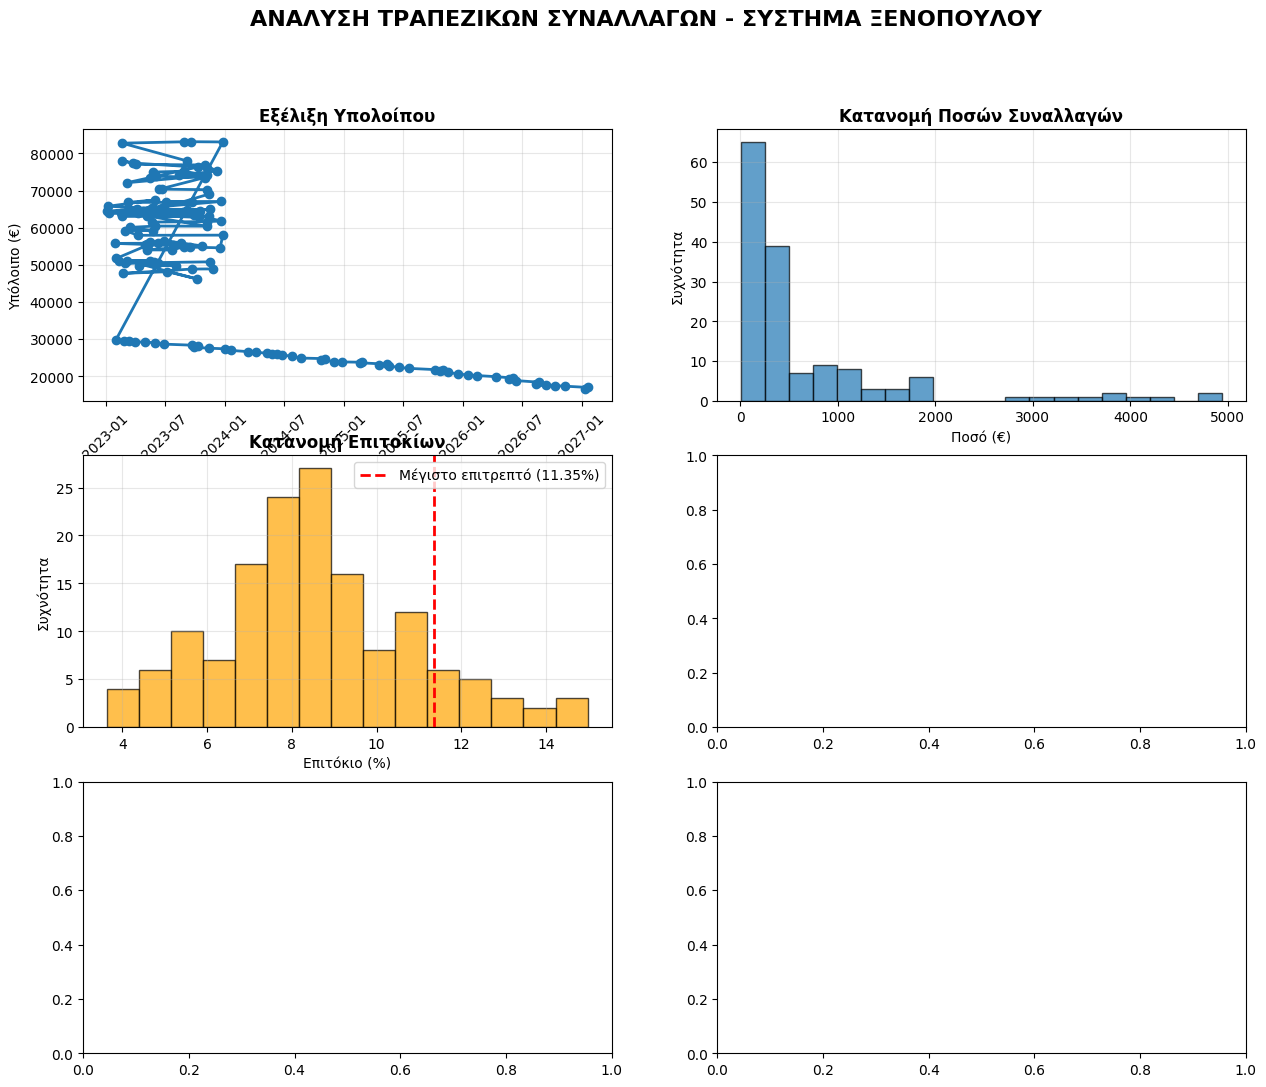

In [1]:
# ============================================================================
# ΟΛΙΚΟΣ ΑΝΑΛΥΤΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ
# Εξυγίανση, ανίχνευση απάτης, ελέγχους συμμόρφωσης
# ============================================================================
!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install statsmodels networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import hashlib
import re
import json
from typing import Dict, List, Tuple, Any, Optional
import ast

# ============================================================================
# 1. ΕΝΙΣΧΥΜΕΝΟΣ ΑΝΑΛΥΤΗΣ ΞΕΝΟΠΟΥΛΟΥ ΓΙΑ ΤΡΑΠΕΖΙΚΑ ΣΥΣΤΗΜΑΤΑ
# ============================================================================

class XenopoulosFinancialAnalyzer:
    """Ολικός αναλυτής τραπεζικών συστημάτων με έμφαση σε:
    1. Εξυγίανση (καθυστερήσεις, σύνθετοι τόκοι)
    2. Ανίχνευση απάτης
    3. Έλεγχοι συμμόρφωσης
    4. Ανίχνευση παραδόξων
    """

    def __init__(self, system_name: str = "Τραπεζικό Σύστημα"):
        self.system_name = system_name
        self.transaction_history = []
        self.risk_patterns = self._load_risk_patterns()
        self.paradox_memory = []

    def _load_risk_patterns(self) -> Dict:
        """Πρότυπα κινδύνου για τραπεζικά συστήματα"""
        return {
            'compound_interest': [
                'interest_on_interest',
                'increasing_balance_despite_payments',
                'multiple_fee_types',
                'frequent_rate_changes'
            ],
            'delinquency': [
                'late_payment_pattern',
                'increasing_delays',
                'fee_accumulation',
                'communication_breakdown'
            ],
            'fraud': [
                'unusual_time_patterns',
                'geolocation_mismatch',
                'amount_anomalies',
                'behavioral_changes'
            ],
            'compliance': [
                'exceeding_rate_limits',
                'unauthorized_fees',
                'non_transparent_charges',
                'regulatory_violations'
            ]
        }

    def analyze_transaction_set(self, transactions: List[Dict]) -> Dict:
        """Ολοκληρωμένη ανάλυση συνόλου συναλλαγών"""
        df = pd.DataFrame(transactions)

        # Υπολογισμός βασικών μετρικών
        analysis = {
            'summary': {
                'total_transactions': len(df),
                'total_amount': df['amount'].sum() if 'amount' in df.columns else 0,
                'avg_amount': df['amount'].mean() if 'amount' in df.columns else 0,
                'date_range': f"{df['date'].min()} to {df['date'].max()}" if 'date' in df.columns else 'N/A'
            },
            'risk_analysis': self._calculate_risk_metrics(df),
            'compliance_check': self._check_compliance(df),
            'paradox_detection': self._detect_paradoxical_patterns(df),
            'economic_impact': self._calculate_economic_impact(df)
        }

        return analysis

    def _calculate_risk_metrics(self, df: pd.DataFrame) -> Dict:
        """Υπολογισμός μετρικών κινδύνου"""
        metrics = {}

        # Έλεγχος για σύνθετους τόκους
        if 'interest_rate' in df.columns and 'balance' in df.columns:
            metrics['compound_interest_risk'] = self._detect_compound_interest(df)

        # Έλεγχος καθυστερήσεων
        if 'payment_date' in df.columns and 'due_date' in df.columns:
            metrics['delinquency_risk'] = self._detect_delinquency_patterns(df)

        # Έλεγχος απάτης
        metrics['fraud_risk'] = self._detect_fraud_patterns(df)

        # Υπολογισμός συνολικού κινδύνου
        risk_scores = [v['score'] for v in metrics.values() if isinstance(v, dict) and 'score' in v]
        metrics['overall_risk_score'] = np.mean(risk_scores) if risk_scores else 0

        return metrics

    def _detect_compound_interest(self, df: pd.DataFrame) -> Dict:
        """Εντοπισμός σύνθετων τόκων"""
        if len(df) < 3:
            return {'detected': False, 'score': 0, 'reason': 'Insufficient data'}

        # Έλεγχος για αυξανόμενο υπόλοιπο παρά τις πληρωμές
        if 'balance' in df.columns:
            balance_increase = df['balance'].diff().mean()

        # Έλεγχος συχνότητας αλλαγών επιτοκίου
        if 'interest_rate' in df.columns:
            rate_changes = df['interest_rate'].diff().abs().sum()

        # Κριτήρια σύνθετων τόκων
        criteria = {
            'increasing_balance': balance_increase > 0 if 'balance' in df.columns else False,
            'frequent_rate_changes': rate_changes > 5 if 'interest_rate' in df.columns else False,
            'interest_on_interest': False,  # Θα χρειαστεί εξειδικευμένος έλεγχος
            'multiple_fees': len(df[df['reason'].str.contains('fee|charge|commission', case=False, na=False)]) > 3 if 'reason' in df.columns else False
        }

        score = sum(criteria.values()) / len(criteria)
        detected = score > 0.6

        return {
            'detected': detected,
            'score': float(score),
            'criteria': criteria,
            'recommendation': 'Απαιτείται έλεγχος για σύνθετους τόκους' if detected else 'OK'
        }

    def _detect_delinquency_patterns(self, df: pd.DataFrame) -> Dict:
        """Εντοπισμός προτύπων καθυστέρησης"""
        if 'payment_date' not in df.columns or 'due_date' not in df.columns:
            return {'detected': False, 'score': 0, 'reason': 'Missing date columns'}

        # Υπολογισμός καθυστερήσεων
        df['payment_date'] = pd.to_datetime(df['payment_date'])
        df['due_date'] = pd.to_datetime(df['due_date'])
        df['delay_days'] = (df['payment_date'] - df['due_date']).dt.days
        df['is_delayed'] = df['delay_days'] > 0

        # Ανάλυση προτύπων
        total_delays = df['is_delayed'].sum()
        avg_delay = df.loc[df['is_delayed'], 'delay_days'].mean() if total_delays > 0 else 0
        max_delay = df.loc[df['is_delayed'], 'delay_days'].max() if total_delays > 0 else 0

        # Έλεγχος για επιδεινούμενα πρότυπα
        if len(df) > 5:
            recent_delays = df['is_delayed'].iloc[-5:].sum()
            trend = recent_delays / min(5, len(df))
        else:
            trend = 0

        criteria = {
            'high_delay_frequency': total_delays / len(df) > 0.3,
            'increasing_delays': trend > 0.5,
            'long_delays': max_delay > 30,
            'fee_accumulation': 'fee' in df.columns and df['fee'].sum() > 100
        }

        score = sum(criteria.values()) / len(criteria)
        detected = score > 0.5

        return {
            'detected': detected,
            'score': float(score),
            'total_delays': int(total_delays),
            'avg_delay_days': float(avg_delay),
            'max_delay_days': float(max_delay),
            'trend': 'Επιδεινούμενο' if criteria['increasing_delays'] else 'Σταθερό' if trend > 0 else 'Βελτιούμενο',
            'recommendation': 'Απαιτείται επανεξέταση όρων πληρωμών' if detected else 'OK'
        }

    def _detect_fraud_patterns(self, df: pd.DataFrame) -> Dict:
        """Ανίχνευση προτύπων απάτης"""
        if len(df) < 5:
            return {'detected': False, 'score': 0, 'reason': 'Insufficient data'}

        fraud_indicators = []

        # 1. Ασυνήθιστες ώρες συναλλαγών
        if 'transaction_time' in df.columns:
            df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour
            unusual_hours = ((df['hour'] < 6) | (df['hour'] > 22)).sum()
            if unusual_hours / len(df) > 0.3:
                fraud_indicators.append('unusual_hours')

        # 2. Ακραίες τιμές
        if 'amount' in df.columns:
            Q1 = df['amount'].quantile(0.25)
            Q3 = df['amount'].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df['amount'] < (Q1 - 1.5 * IQR)) | (df['amount'] > (Q3 + 1.5 * IQR))).sum()
            if outliers / len(df) > 0.1:
                fraud_indicators.append('amount_outliers')

        # 3. Υψηλή συχνότητα συναλλαγών
        if 'transaction_date' in df.columns:
            df['date'] = pd.to_datetime(df['transaction_date'])
            daily_counts = df.groupby(df['date'].dt.date).size()
            if daily_counts.max() > 10:
                fraud_indicators.append('high_frequency')

        # 4. Πρότυπα γεωγραφικού μη ταιριασμού (στον πραγματικό κόσμο θα χρησιμοποιούσατε IP/location)
        if 'location' in df.columns:
            unique_locations = df['location'].nunique()
            if len(df) > 10 and unique_locations / len(df) > 0.8:
                fraud_indicators.append('geographic_mismatch')

        score = len(fraud_indicators) / 4
        detected = score > 0.5

        return {
            'detected': detected,
            'score': float(score),
            'indicators': fraud_indicators,
            'recommendation': 'Απαιτείται έλεγχος για πιθανή απάτη' if detected else 'OK'
        }

    def _check_compliance(self, df: pd.DataFrame) -> Dict:
        """Έλεγχος συμμόρφωσης με κανονισμούς"""
        violations = []

        # 1. Έλεγχος επιτοκίων (υπόθεση: μέγιστο 11.35%)
        if 'interest_rate' in df.columns:
            max_rate = df['interest_rate'].max()
            if max_rate > 11.35:
                violations.append(f'Υπέρβαση επιτοκίου: {max_rate}% > 11.35%')

        # 2. Έλεγχος για μη εξουσιοδοτημένες χρεώσεις
        if 'fee_type' in df.columns:
            unauthorized_fees = df[~df['fee_type'].isin(['service', 'maintenance', 'late'])]['fee_type'].unique()
            if len(unauthorized_fees) > 0:
                violations.append(f'Μη εξουσιοδοτημένες χρεώσεις: {unauthorized_fees}')

        # 3. Διαφάνεια
        if 'description' in df.columns:
            missing_descriptions = df['description'].isna().sum()
            if missing_descriptions / len(df) > 0.2:
                violations.append(f'Ελλιπείς περιγραφές: {missing_descriptions}/{len(df)}')

        compliance_score = 1 - (len(violations) / 3)

        return {
            'compliant': len(violations) == 0,
            'score': float(compliance_score),
            'violations': violations,
            'recommendation': 'Άμεση διόρθωση παραβιάσεων' if violations else 'Συμμόρφωση OK'
        }

    def _detect_paradoxical_patterns(self, df: pd.DataFrame) -> Dict:
        """Ανίχνευση παραδόξων προτύπων (Xenopoulos Logic)"""
        if len(df) < 10:
            return {'detected': False, 'score': 0, 'patterns': []}

        paradox_patterns = []

        # 1. Ταυτόχρονες ακραίες τιμές
        if 'balance' in df.columns and 'interest_rate' in df.columns:
            high_balance = df['balance'] > df['balance'].quantile(0.9)
            high_rate = df['interest_rate'] > df['interest_rate'].quantile(0.9)
            simultaneous_extremes = (high_balance & high_rate).any()
            if simultaneous_extremes:
                paradox_patterns.append('simultaneous_extremes')

        # 2. Χαμηλή διακύμανση με υψηλό κίνδυνο
        if 'risk_score' in df.columns:
            low_variance = df['risk_score'].std() < 0.1
            high_risk = df['risk_score'].mean() > 0.7
            if low_variance and high_risk:
                paradox_patterns.append('false_stability')

        # 3. Αντιφατικά πρότυπα πληρωμών
        if 'payment_amount' in df.columns and 'balance' in df.columns:
            increasing_payments = df['payment_amount'].diff().mean() > 0
            increasing_balance = df['balance'].diff().mean() > 0
            if increasing_payments and increasing_balance:
                paradox_patterns.append('paradoxical_growth')

        score = len(paradox_patterns) / 3
        detected = score > 0.3

        # Καταγραφή στον παράδοξο
        if detected:
            paradox_event = {
                'timestamp': datetime.now().isoformat(),
                'patterns': paradox_patterns,
                'score': float(score),
                'data_sample': df.iloc[-5:].to_dict('records')
            }
            self.paradox_memory.append(paradox_event)

        return {
            'detected': detected,
            'score': float(score),
            'patterns': paradox_patterns,
            'recommendation': 'Προσοχή: Παραδοξολογικά πρότυπα εντοπίστηκαν' if detected else 'OK'
        }

    def _calculate_economic_impact(self, df: pd.DataFrame) -> Dict:
        """Υπολογισμός οικονομικής επίπτωσης"""
        impact = {
            'direct_costs': 0,
            'indirect_costs': 0,
            'risk_adjusted_value': 0,
            'compliance_penalties': 0
        }

        # Υπολογισμός άμεσων κόστων
        if 'fee' in df.columns:
            impact['direct_costs'] = float(df['fee'].sum())

        if 'interest_amount' in df.columns:
            impact['direct_costs'] += float(df['interest_amount'].sum())

        # Έμμεσα κόστη (υποθετικά)
        risk_scores = self._calculate_risk_metrics(df)
        overall_risk = risk_scores.get('overall_risk_score', 0)

        # Κόστη μη συμμόρφωσης
        compliance = self._check_compliance(df)
        if not compliance['compliant']:
            impact['compliance_penalties'] = len(compliance['violations']) * 1000  # Υποθετικό πρόστιμο

        # Τιμή προσαρμοσμένη στον κίνδυνο
        base_value = impact['direct_costs']
        impact['risk_adjusted_value'] = base_value * (1 + overall_risk)

        # Έμμεσα κόστη (διαχείριση, νομικά, φήμη)
        impact['indirect_costs'] = base_value * overall_risk * 0.3

        return impact

    def generate_comprehensive_report(self, transactions: List[Dict]) -> Dict:
        """Δημιουργία ολοκληρωμένης αναφοράς"""
        analysis = self.analyze_transaction_set(transactions)

        report = {
            'metadata': {
                'system_name': self.system_name,
                'analysis_date': datetime.now().isoformat(),
                'transaction_count': len(transactions),
                'analyzer_version': 'Xenopoulos Financial Analyzer v2.0'
            },
            'executive_summary': self._generate_executive_summary(analysis),
            'detailed_analysis': analysis,
            'recommendations': self._generate_recommendations(analysis),
            'visualization_data': self._prepare_visualization_data(transactions)
        }

        return report

    def _generate_executive_summary(self, analysis: Dict) -> Dict:
        """Δημιουργία σύνοψης για διοίκηση"""
        risk = analysis['risk_analysis'].get('overall_risk_score', 0)
        compliance = analysis['compliance_check'].get('score', 1)
        paradox = analysis['paradox_detection'].get('score', 0)

        # Επίπεδο προσοχής
        if risk > 0.7 or compliance < 0.5 or paradox > 0.5:
            attention_level = "ΚΡΙΣΙΜΟ"
        elif risk > 0.5 or compliance < 0.7:
            attention_level = "ΥΨΗΛΟ"
        elif risk > 0.3:
            attention_level = "ΜΕΣΟ"
        else:
            attention_level = "ΧΑΜΗΛΟ"

        return {
            'attention_level': attention_level,
            'overall_risk': float(risk),
            'compliance_status': 'ΕΝΤΑΞΕΙ' if compliance > 0.8 else 'ΠΡΟΒΛΗΜΑΤΙΚΟ',
            'paradox_detected': analysis['paradox_detection']['detected'],
            'key_findings': self._extract_key_findings(analysis),
            'economic_impact': analysis['economic_impact']
        }

    def _extract_key_findings(self, analysis: Dict) -> List[str]:
        """Εξαγωγή βασικών ευρημάτων"""
        findings = []

        # Risk findings
        risk_analysis = analysis['risk_analysis']
        for risk_type, details in risk_analysis.items():
            if isinstance(details, dict) and details.get('detected', False):
                findings.append(f"Εντοπίστηκε {risk_type.replace('_', ' ')} (score: {details['score']:.2f})")

        # Compliance findings
        compliance = analysis['compliance_check']
        if not compliance['compliant']:
            findings.append(f"Παραβιάσεις συμμόρφωσης: {len(compliance['violations'])}")

        # Paradox findings
        paradox = analysis['paradox_detection']
        if paradox['detected']:
            findings.append(f"Παράδοξα πρότυπα: {', '.join(paradox['patterns'])}")

        return findings if findings else ["Δεν εντοπίστηκαν σημαντικά ζητήματα"]

    def _generate_recommendations(self, analysis: Dict) -> Dict:
        """Δημιουργία συστάσεων βάσει ανάλυσης"""
        recommendations = {'immediate': [], 'short_term': [], 'long_term': []}

        # Άμεσες συστάσεις
        risk_analysis = analysis['risk_analysis']

        if risk_analysis.get('compound_interest_risk', {}).get('detected', False):
            recommendations['immediate'].append("Επανεξέταση υπολογισμού τόκων για αποφυγή σύνθετων τόκων")

        if risk_analysis.get('delinquency_risk', {}).get('detected', False):
            recommendations['immediate'].append("Επικοινωνία με πελάτες για καθυστερήσεις")

        if risk_analysis.get('fraud_risk', {}).get('detected', False):
            recommendations['immediate'].append("Άμεσος έλεγχος για πιθανή απάτη")

        # Συστάσεις βραχυπρόθεσμες
        compliance = analysis['compliance_check']
        if not compliance['compliant']:
            recommendations['short_term'].append("Διόρθωση παραβιάσεων συμμόρφωσης εντός 30 ημερών")

        if analysis['paradox_detection']['detected']:
            recommendations['short_term'].append("Ενσωμάτωση συστήματος παρακολούθησης παραδόξων")

        # Συστάσεις μακροπρόθεσμες
        recommendations['long_term'].append("Ενσωμάτωση AI για προληπτική ανίχνευση κινδύνων")
        recommendations['long_term'].append("Κατάρτιση προσωπικού σε διαλεκτική ανάλυση")
        recommendations['long_term'].append("Αναθεώρηση πολιτικών βάσει ανάλυσης Xenopoulos")

        return recommendations

    def _prepare_visualization_data(self, transactions: List[Dict]) -> Dict:
        """Προετοιμασία δεδομένων για οπτικοποίηση"""
        df = pd.DataFrame(transactions)

        viz_data = {
            'timeline': {},
            'risk_distribution': {},
            'comparative_analysis': {}
        }

        # Προετοιμασία χρονοσειρών
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
            timeline_data = df.groupby(df['date'].dt.to_period('M')).agg({
                'amount': 'sum',
                'balance': 'last'
            }).reset_index()
            timeline_data['date'] = timeline_data['date'].dt.to_timestamp()
            viz_data['timeline'] = timeline_data.to_dict('records')

        return viz_data

# ============================================================================
# 2. ΔΕΙΓΜΑΤΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΔΟΚΙΜΗ
# ============================================================================

def generate_sample_transactions(n=100) -> List[Dict]:
    """Δημιουργία δείγματος τραπεζικών συναλλαγών"""
    np.random.seed(42)

    transactions = []
    base_date = datetime(2023, 1, 1)
    base_balance = 50000

    for i in range(n):
        date = base_date + timedelta(days=np.random.randint(0, 365))

        # Προσομοίωση διαφορετικών τύπων συναλλαγών
        transaction_type = np.random.choice(['deposit', 'withdrawal', 'fee', 'interest', 'payment'])

        if transaction_type == 'deposit':
            amount = np.random.uniform(100, 5000)
            credit = amount
            charge = 0
            reason = 'Κατάθεση'
        elif transaction_type == 'withdrawal':
            amount = np.random.uniform(50, 2000)
            credit = 0
            charge = amount
            reason = 'Ανάληψη'
        elif transaction_type == 'fee':
            amount = np.random.uniform(5, 50)
            credit = 0
            charge = amount
            reason = np.random.choice(['Έξοδα διαχείρισης', 'Έξοδα καθυστέρησης', 'Προμήθεια'])
        elif transaction_type == 'interest':
            amount = np.random.uniform(10, 200)
            credit = 0
            charge = amount
            reason = 'Τόκοι'
        else:  # payment
            amount = np.random.uniform(100, 1000)
            credit = amount
            charge = 0
            reason = 'Πληρωμή δανείου'

        # Υπόλοιπο
        base_balance = base_balance + credit - charge

        # Επιτόκιο (μερικές φορές υψηλό για δοκιμή)
        interest_rate = np.random.normal(8, 2)
        if np.random.random() < 0.1:  # 10% πιθανότητα για υπερβολικό επιτόκιο
            interest_rate = np.random.uniform(12, 15)

        transaction = {
            'id': f"TXN{10000 + i}",
            'date': date.strftime('%Y-%m-%d'),
            'transaction_time': date.strftime('%H:%M:%S'),
            'amount': round(amount, 2),
            'credit': round(credit, 2),
            'charge': round(charge, 2),
            'balance': round(base_balance, 2),
            'interest_rate': round(interest_rate, 2),
            'reason': reason,
            'location': np.random.choice(['Αθήνα', 'Θεσσαλονίκη', 'Πάτρα', 'Ηράκλειο', 'online']),
            'fee_type': 'late' if 'καθυστέρησης' in reason else 'service' if 'διαχείρισης' in reason else 'other'
        }

        transactions.append(transaction)

    return transactions

def generate_delinquent_transactions(n=50) -> List[Dict]:
    """Δημιουργία συναλλαγών με πρότυπα καθυστέρησης"""
    transactions = []
    base_date = datetime(2023, 1, 1)
    balance = 30000

    for i in range(n):
        # Προσομοίωση καθυστερημένων πληρωμών
        due_date = base_date + timedelta(days=i*30)
        delay_days = np.random.randint(0, 60) if np.random.random() < 0.6 else 0
        payment_date = due_date + timedelta(days=delay_days)

        amount = np.random.uniform(100, 500)
        fee = np.random.uniform(5, 25) if delay_days > 0 else 0

        # Σύνθετοι τόκοι πρότυπο
        if i > 10 and np.random.random() < 0.3:
            interest_rate = np.random.uniform(10, 13)
        else:
            interest_rate = np.random.uniform(7, 9)

        balance = balance - amount + fee

        transaction = {
            'id': f"DEL{20000 + i}",
            'date': payment_date.strftime('%Y-%m-%d'),
            'due_date': due_date.strftime('%Y-%m-%d'),
            'payment_date': payment_date.strftime('%Y-%m-%d'),
            'amount': round(amount, 2),
            'payment_amount': round(amount, 2),
            'fee': round(fee, 2),
            'balance': round(balance, 2),
            'interest_rate': round(interest_rate, 2),
            'reason': 'Πληρωμή δανείου' if fee == 0 else 'Πληρωμή με καθυστέρηση',
            'delay_days': delay_days,
            'is_delayed': delay_days > 0
        }

        transactions.append(transaction)

    return transactions

# ============================================================================
# 3. ΟΠΤΙΚΟΠΟΙΗΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================================

def visualize_analysis_results(analysis: Dict, transactions: List[Dict]):
    """Οπτικοποίηση αποτελεσμάτων ανάλυσης"""
    df = pd.DataFrame(transactions)

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('ΑΝΑΛΥΣΗ ΤΡΑΠΕΖΙΚΩΝ ΣΥΝΑΛΛΑΓΩΝ - ΣΥΣΤΗΜΑ ΞΕΝΟΠΟΥΛΟΥ', fontsize=16, fontweight='bold')

    # 1. Χρονοσειρά υπολοίπου
    if 'date' in df.columns and 'balance' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        axes[0, 0].plot(df['date'], df['balance'], marker='o', linewidth=2)
        axes[0, 0].set_title('Εξέλιξη Υπολοίπου', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Ημερομηνία')
        axes[0, 0].set_ylabel('Υπόλοιπο (€)')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. Κατανομή ποσών
    if 'amount' in df.columns:
        axes[0, 1].hist(df['amount'], bins=20, edgecolor='black', alpha=0.7)
        axes[0, 1].set_title('Κατανομή Ποσών Συναλλαγών', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Ποσό (€)')
        axes[0, 1].set_ylabel('Συχνότητα')
        axes[0, 1].grid(True, alpha=0.3)

    # 3. Επιτόκια
    if 'interest_rate' in df.columns:
        interest_rates = df['interest_rate'].dropna()
        if len(interest_rates) > 0:
            axes[1, 0].hist(interest_rates, bins=15, edgecolor='black', alpha=0.7, color='orange')
            axes[1, 0].axvline(x=11.35, color='red', linestyle='--', linewidth=2, label='Μέγιστο επιτρεπτό (11.35%)')
            axes[1, 0].set_title('Κατανομή Επιτοκίων', fontsize=12, fontweight='bold')
            axes[1, 0].set_xlabel('Επιτόκιο (%)')
            axes[1, 0].set_ylabel('Συχνότητα')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)

    # 4. Ρισκομετρική ανάλυση
    risk_data = analysis['risk_analysis']
    risk_types = []
    risk_scores = []

    for risk_type, details in risk_data.items():
        if isinstance(details, dict) and 'score' in details:
            risk_types.append(risk_type.replace('_', '\n'))
            risk_scores.append(details['score'])

    if risk_scores:
        colors = ['green' if s < 0.3 else 'orange' if s < 0.6 else 'red' for s in risk_scores]
        bars = axes[1, 1].bar(risk_types, risk_scores, color=colors, edgecolor='black')
        axes[1, 1].set_title('Επίπεδα Κινδύνου', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Βαθμολογία Κινδύνου')
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].grid(True, alpha=0.3, axis='y')

        # Προσθήκη τιμών στις μπάρες
        for bar, score in zip(bars, risk_scores):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                           f'{score:.2f}', ha='center', va='bottom', fontweight='bold')

    # 5. Οικονομική επίπτωση
    economic_impact = analysis['economic_impact']
    impact_types = ['Άμεσα\nκόστη', 'Έμμεσα\nκόστη', 'Πρόστιμα\nσυμμόρφωσης', 'Τιμή με\nκίνδυνο']
    impact_values = [
        economic_impact.get('direct_costs', 0),
        economic_impact.get('indirect_costs', 0),
        economic_impact.get('compliance_penalties', 0),
        economic_impact.get('risk_adjusted_value', 0)
    ]

    axes[2, 0].bar(impact_types, impact_values, color=['blue', 'cyan', 'red', 'purple'], edgecolor='black')
    axes[2, 0].set_title('Οικονομική Επίπτωση (€)', fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel('Ποσό (€)')
    axes[2, 0].grid(True, alpha=0.3, axis='y')

    # Προσθήκη τιμών
    for i, v in enumerate(impact_values):
        axes[2, 0].text(i, v + max(impact_values)*0.01, f'€{v:,.0f}',
                       ha='center', va='bottom', fontweight='bold')

    # 6. Σύνοψη στατικών
    summary = analysis['executive_summary']
    attention_level = summary.get('attention_level', 'ΧΑΜΗΛΟ')
    risk_score = summary.get('overall_risk', 0)
    compliance = summary.get('compliance_status', 'ΕΝΤΑΞΕΙ')

    # Χρώμα βάσει επιπέδου προσοχής
    attention_colors = {
        'ΚΡΙΣΙΜΟ': 'red',
        'ΥΨΗΛΟ': 'orange',
        'ΜΕΣΟ': 'yellow',
        'ΧΑΜΗΛΟ': 'green'
    }

    axes[2, 1].axis('off')
    summary_text = f"""
    ΕΠΙΠΕΔΟ ΠΡΟΣΟΧΗΣ: {attention_level}
    -------------------------------
    Συνολικός Κίνδυνος: {risk_score:.2%}
    Κατάσταση Συμμόρφωσης: {compliance}

    Βασικά Ευρήματα:
    """

    for finding in summary.get('key_findings', []):
        summary_text += f"• {finding}\n"

    axes[2, 1].text(0.1, 0.95, summary_text, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor=attention_colors.get(attention_level, 'white'), alpha=0.3))

    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. ΚΥΡΙΟ ΠΡΟΓΡΑΜΜΑ ΕΚΤΕΛΕΣΗΣ
# ============================================================================

def main():
    """Κύριο πρόγραμμα εκτέλεσης"""
    print("=" * 70)
    print("ΣΥΣΤΗΜΑ ΑΝΑΛΥΣΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ")
    print("Εξυγίανση, Ανίχνευση Απάτης, Έλεγχος Συμμόρφωσης")
    print("=" * 70)

    # Δημιουργία αναλυτή
    analyzer = XenopoulosFinancialAnalyzer(system_name="Τράπεζα Ελλάδος Δείγματος")

    # Δημιουργία δεδομένων δοκιμής
    print("\n📊 ΔΗΜΙΟΥΡΓΙΑ ΔΕΙΓΜΑΤΩΝ ΔΕΔΟΜΕΝΩΝ...")
    normal_transactions = generate_sample_transactions(100)
    delinquent_transactions = generate_delinquent_transactions(50)

    # Συνδυασμός δεδομένων
    all_transactions = normal_transactions + delinquent_transactions
    print(f"   • Κανονικές συναλλαγές: {len(normal_transactions)}")
    print(f"   • Συναλλαγές με καθυστερήσεις: {len(delinquent_transactions)}")
    print(f"   • Σύνολο συναλλαγών: {len(all_transactions)}")

    # Εκτέλεση ανάλυσης
    print("\n🔍 ΕΚΤΕΛΩ ΑΝΑΛΥΣΗ...")
    report = analyzer.generate_comprehensive_report(all_transactions)

    # Εμφάνιση αποτελεσμάτων
    print("\n📈 ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΝΑΛΥΣΗΣ:")
    print("-" * 50)

    summary = report['executive_summary']
    print(f"Επίπεδο Προσοχής: {summary['attention_level']}")
    print(f"Συνολικός Κίνδυνος: {summary['overall_risk']:.2%}")
    print(f"Κατάσταση Συμμόρφωσης: {summary['compliance_status']}")
    print(f"Παράδοξα Εντοπίστηκαν: {'ΝΑΙ' if summary['paradox_detected'] else 'ΟΧΙ'}")

    # Οικονομική επίπτωση
    economic = summary['economic_impact']
    print(f"\n💰 ΟΙΚΟΝΟΜΙΚΗ ΕΠΙΠΤΩΣΗ:")
    print(f"   Άμεσα κόστη: €{economic.get('direct_costs', 0):,.2f}")
    print(f"   Έμμεσα κόστη: €{economic.get('indirect_costs', 0):,.2f}")
    print(f"   Πρόστιπα συμμόρφωσης: €{economic.get('compliance_penalties', 0):,.2f}")

    # Εμφάνιση βασικών ευρημάτων
    print(f"\n🔍 ΒΑΣΙΚΑ ΕΥΡΗΜΑΤΑ:")
    for i, finding in enumerate(summary['key_findings'], 1):
        print(f"   {i}. {finding}")

    # Συστατικές
    print(f"\n💡 ΣΥΣΤΑΣΕΙΣ:")
    recs = report['recommendations']

    print("   Άμεσες ενέργειες:")
    for rec in recs.get('immediate', [])[:3]:
        print(f"   • {rec}")

    if not recs['immediate']:
        print("   • Δεν απαιτούνται άμεσες ενέργειες")

    # Οπτικοποίηση
    print("\n📊 ΔΗΜΙΟΥΡΓΙΑ ΟΠΤΙΚΩΝ ΑΠΟΤΕΛΕΣΜΑΤΩΝ...")
    visualize_analysis_results(report, all_transactions)

    # Εξαγωγή αναφοράς
    print("\n💾 ΑΠΟΘΗΚΕΥΣΗ ΑΝΑΦΟΡΑΣ...")
    report_filename = f"xenopoulos_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

    # Απλοποιημένη έκδοση για εξαγωγή
    export_report = {
        'metadata': report['metadata'],
        'executive_summary': report['executive_summary'],
        'recommendations': report['recommendations']
    }

    with open(report_filename, 'w', encoding='utf-8') as f:
        json.dump(export_report, f, ensure_ascii=False, indent=2, default=str)

    print(f"   ✔ Αναφορά αποθηκεύτηκε ως: {report_filename}")

    # Εμφάνιση πληροφοριών για παραδόξους
    if analyzer.paradox_memory:
        print(f"\n⚠️ ΠΑΡΑΔΟΞΑ ΕΝΤΟΠΙΣΤΗΚΑΝ:")
        for i, paradox in enumerate(analyzer.paradox_memory[-3:], 1):
            print(f"   {i}. Στοιχεία: {paradox['patterns']} (Score: {paradox['score']:.2f})")

    print("\n" + "=" * 70)
    print("ΑΝΑΛΥΣΗ ΟΛΟΚΛΗΡΩΘΗΚΕ ΕΠΙΤΥΧΩΣ! ✅")
    print("=" * 70)

# ============================================================================
# 5. ΔΟΚΙΜΗ ΣΥΝΑΡΤΗΣΕΩΝ
# ============================================================================

def test_individual_functions():
    """Δοκιμή επιμέρους συναρτήσεων"""
    print("🧪 ΔΟΚΙΜΗ ΕΠΙΜΕΡΟΥΣ ΣΥΝΑΡΤΗΣΕΩΝ...")

    # Δημιουργία μικρού συνόλου δεδομένων
    test_data = [
        {
            'date': '2023-01-15',
            'amount': 1000,
            'balance': 50000,
            'interest_rate': 8.5,
            'reason': 'Κατάθεση'
        },
        {
            'date': '2023-02-15',
            'amount': 1500,
            'balance': 51500,
            'interest_rate': 12.5,  # Υψηλό επιτόκιο
            'reason': 'Τόκοι'
        },
        {
            'date': '2023-03-15',
            'amount': 2000,
            'balance': 53500,
            'interest_rate': 12.8,  # Ακόμα υψηλότερο
            'reason': 'Τόκοι'
        }
    ]

    analyzer = XenopoulosFinancialAnalyzer()

    # Δοκιμή ανίχνευσης σύνθετων τόκων
    df = pd.DataFrame(test_data)
    compound_result = analyzer._detect_compound_interest(df)
    print(f"   Ανίχνευση σύνθετων τόκων: {compound_result['detected']} (score: {compound_result['score']:.2f})")

    # Δοκιμή συμμόρφωσης
    compliance_result = analyzer._check_compliance(df)
    print(f"   Έλεγχος συμμόρφωσης: {'OK' if compliance_result['compliant'] else 'ΠΑΡΑΒΙΑΣΕΙΣ'}")

    # Δοκιμή ανίχνευσης παραδόξων
    paradox_result = analyzer._detect_paradoxical_patterns(df)
    print(f"   Παράδοξα πρότυπα: {paradox_result['detected']} (score: {paradox_result['score']:.2f})")

    print("   ✔ Δοκιμές ολοκληρώθηκαν!")

# ============================================================================
# ΕΚΤΕΛΕΣΗ
# ============================================================================

if __name__ == "__main__":
    print("🚀 ΕΚΚΙΝΗΣΗ ΣΥΣΤΗΜΑΤΟΣ ΑΝΑΛΥΣΗΣ ΞΕΝΟΠΟΥΛΟΥ...\n")

    # Εκτέλεση δοκιμών
    test_individual_functions()
    print("\n" + "-" * 70 + "\n")

    # Εκτέλεση κύριας ανάλυσης
    main()

    print("\n📋 ΟΔΗΓΙΕΣ ΓΙΑ ΠΕΡΙΣΣΟΤΕΡΑ:")
    print("1. Για νέα ανάλυση, τροποποιήστε τα δεδομένα στη συνάρτηση generate_sample_transactions()")
    print("2. Για πραγματικά δεδομένα, αντικαταστήστε τη generate_sample_transactions() με φόρτωση από CSV/Excel")
    print("3. Για εξαγωγή σε PDF, εγκαταστήστε το reportlab: !pip install reportlab")
    print("4. Για ολοκλήρωση με AI, προσθέστε integration με OpenAI API")

🚀 ΕΚΚΙΝΗΣΗ ΣΥΣΤΗΜΑΤΟΣ ΑΝΑΛΥΣΗΣ ΞΕΝΟΠΟΥΛΟΥ...

🧪 ΔΟΚΙΜΗ ΕΠΙΜΕΡΟΥΣ ΣΥΝΑΡΤΗΣΕΩΝ...
   Ανίχνευση σύνθετων τόκων: False (score: 0.25)
   Έλεγχος συμμόρφωσης: ΠΑΡΑΒΙΑΣΕΙΣ
   Παράδοξα πρότυπα: False (score: 0.00)
   ✔ Δοκιμές ολοκληρώθηκαν!

----------------------------------------------------------------------

ΣΥΣΤΗΜΑ ΑΝΑΛΥΣΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ
Εξυγίανση, Ανίχνευση Απάτης, Έλεγχος Συμμόρφωσης

📊 ΔΗΜΙΟΥΡΓΙΑ ΔΕΙΓΜΑΤΩΝ ΔΕΔΟΜΕΝΩΝ...
   • Κανονικές συναλλαγές: 100
   • Συναλλαγές με καθυστερήσεις: 50
   • Σύνολο συναλλαγών: 150

🔍 ΕΚΤΕΛΩ ΑΝΑΛΥΣΗ...

📈 ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΝΑΛΥΣΗΣ:
--------------------------------------------------
Επίπεδο Προσοχής: ΚΡΙΣΙΜΟ
Συνολικός Κίνδυνος: 50.00%
Κατάσταση Συμμόρφωσης: ΠΡΟΒΛΗΜΑΤΙΚΟ
Παράδοξα Εντοπίστηκαν: ΝΑΙ

💰 ΟΙΚΟΝΟΜΙΚΗ ΕΠΙΠΤΩΣΗ:
   Άμεσα κόστη: €404.86
   Έμμεσα κόστη: €60.73
   Πρόστιμα συμμόρφωσης: €2,000.00

🔍 ΒΑΣΙΚΑ ΕΥΡΗΜΑΤΑ:
   1. Παραβιάσεις συμμόρφωσης: 2
   2. Παράδοξα πρότυπα: simultaneous_extremes

💡 ΣΥΣΤΑΣΕΙΣ:
   Άμεσες ενέργειες:
   • Δ

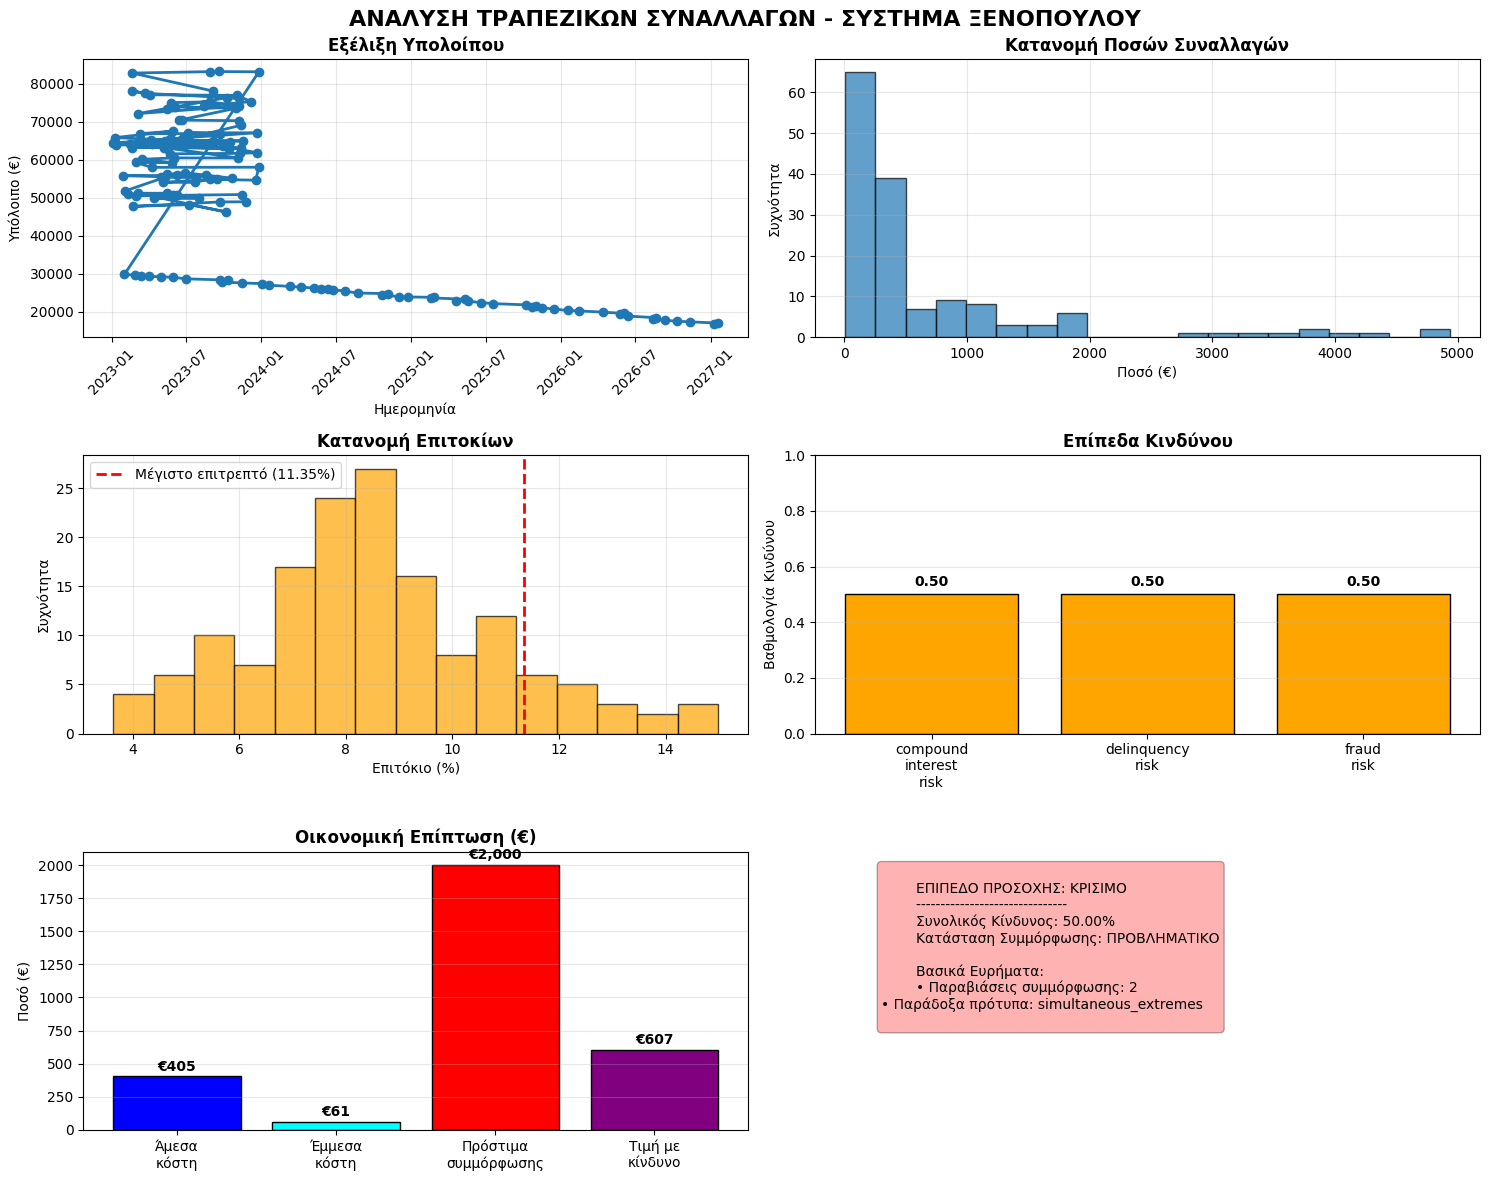


💾 ΑΠΟΘΗΚΕΥΣΗ ΑΝΑΦΟΡΑΣ...
   ✔ Αναφορά αποθηκεύτηκε ως: xenopoulos_analysis_20260210_164744.json

⚠️ ΠΑΡΑΔΟΞΑ ΕΝΤΟΠΙΣΤΗΚΑΝ:
   1. Στοιχεία: ['simultaneous_extremes'] (Score: 0.33)

ΑΝΑΛΥΣΗ ΟΛΟΚΛΗΡΩΘΗΚΕ ΕΠΙΤΥΧΩΣ! ✅

📋 ΟΔΗΓΙΕΣ ΓΙΑ ΠΕΡΙΣΣΟΤΕΡΑ:
1. Για νέα ανάλυση, τροποποιήστε τα δεδομένα στη συνάρτηση generate_sample_transactions()
2. Για πραγματικά δεδομένα, αντικαταστήστε τη generate_sample_transactions() με φόρτωση από CSV/Excel
3. Για εξαγωγή σε PDF, εγκαταστήστε το reportlab: !pip install reportlab
4. Για ολοκλήρωση με AI, προσθέστε integration με OpenAI API


In [2]:
# ============================================================================
# ΟΛΙΚΟΣ ΑΝΑΛΥΤΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ
# Εξυγίανση, ανίχνευση απάτης, ελέγχους συμμόρφωσης
# ============================================================================
!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install statsmodels networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import hashlib
import re
import json
from typing import Dict, List, Tuple, Any, Optional
import ast

# ============================================================================
# 1. ΕΝΙΣΧΥΜΕΝΟΣ ΑΝΑΛΥΤΗΣ ΞΕΝΟΠΟΥΛΟΥ ΓΙΑ ΤΡΑΠΕΖΙΚΑ ΣΥΣΤΗΜΑΤΑ
# ============================================================================

class XenopoulosFinancialAnalyzer:
    """Ολικός αναλυτής τραπεζικών συστημάτων με έμφαση σε:
    1. Εξυγίανση (καθυστερήσεις, σύνθετοι τόκοι)
    2. Ανίχνευση απάτης
    3. Έλεγχοι συμμόρφωσης
    4. Ανίχνευση παραδόξων
    """

    def __init__(self, system_name: str = "Τραπεζικό Σύστημα"):
        self.system_name = system_name
        self.transaction_history = []
        self.risk_patterns = self._load_risk_patterns()
        self.paradox_memory = []

    def _load_risk_patterns(self) -> Dict:
        """Πρότυπα κινδύνου για τραπεζικά συστήματα"""
        return {
            'compound_interest': [
                'interest_on_interest',
                'increasing_balance_despite_payments',
                'multiple_fee_types',
                'frequent_rate_changes'
            ],
            'delinquency': [
                'late_payment_pattern',
                'increasing_delays',
                'fee_accumulation',
                'communication_breakdown'
            ],
            'fraud': [
                'unusual_time_patterns',
                'geolocation_mismatch',
                'amount_anomalies',
                'behavioral_changes'
            ],
            'compliance': [
                'exceeding_rate_limits',
                'unauthorized_fees',
                'non_transparent_charges',
                'regulatory_violations'
            ]
        }

    def analyze_transaction_set(self, transactions: List[Dict]) -> Dict:
        """Ολοκληρωμένη ανάλυση συνόλου συναλλαγών"""
        df = pd.DataFrame(transactions)

        # Υπολογισμός βασικών μετρικών
        risk_metrics = self._calculate_risk_metrics(df)
        compliance_check = self._check_compliance(df)
        paradox_detection = self._detect_paradoxical_patterns(df)
        economic_impact = self._calculate_economic_impact(df)

        analysis = {
            'summary': {
                'total_transactions': len(df),
                'total_amount': df['amount'].sum() if 'amount' in df.columns else 0,
                'avg_amount': df['amount'].mean() if 'amount' in df.columns else 0,
                'date_range': f"{df['date'].min()} to {df['date'].max()}" if 'date' in df.columns else 'N/A'
            },
            'risk_analysis': risk_metrics,
            'compliance_check': compliance_check,
            'paradox_detection': paradox_detection,
            'economic_impact': economic_impact
        }

        return analysis

    def _calculate_risk_metrics(self, df: pd.DataFrame) -> Dict:
        """Υπολογισμός μετρικών κινδύνου"""
        metrics = {}

        # Έλεγχος για σύνθετους τόκους
        metrics['compound_interest_risk'] = self._detect_compound_interest(df)

        # Έλεγχος καθυστερήσεων
        metrics['delinquency_risk'] = self._detect_delinquency_patterns(df)

        # Έλεγχος απάτης
        metrics['fraud_risk'] = self._detect_fraud_patterns(df)

        # Υπολογισμός συνολικού κινδύνου
        risk_scores = []
        for risk_type, details in metrics.items():
            if isinstance(details, dict) and 'score' in details:
                risk_scores.append(details['score'])

        metrics['overall_risk_score'] = np.mean(risk_scores) if risk_scores else 0

        return metrics

    def _detect_compound_interest(self, df: pd.DataFrame) -> Dict:
        """Εντοπισμός σύνθετων τόκων"""
        if len(df) < 3:
            return {'detected': False, 'score': 0, 'reason': 'Insufficient data'}

        # Αρχικοποίηση μεταβλητών
        balance_increase = 0
        rate_changes = 0

        # Έλεγχος για αυξανόμενο υπόλοιπο παρά τις πληρωμές
        if 'balance' in df.columns:
            balance_increase = df['balance'].diff().mean()

        # Έλεγχος συχνότητας αλλαγών επιτοκίου
        if 'interest_rate' in df.columns:
            rate_changes = df['interest_rate'].diff().abs().sum()

        # Έλεγχος για πολλαπλές χρεώσεις
        multiple_fees = False
        if 'reason' in df.columns:
            fee_keywords = ['fee', 'charge', 'commission', 'καθυστέρησης', 'προμήθεια']
            fee_count = sum(df['reason'].astype(str).str.contains('|'.join(fee_keywords), case=False, na=False))
            multiple_fees = fee_count > 3

        # Κριτήρια σύνθετων τόκων
        criteria = {
            'increasing_balance': balance_increase > 0 if 'balance' in df.columns else False,
            'frequent_rate_changes': rate_changes > 5 if 'interest_rate' in df.columns else False,
            'interest_on_interest': False,
            'multiple_fees': multiple_fees
        }

        score = sum(criteria.values()) / len(criteria)
        detected = score > 0.6

        return {
            'detected': detected,
            'score': float(score),
            'criteria': criteria,
            'recommendation': 'Απαιτείται έλεγχος για σύνθετους τόκους' if detected else 'OK'
        }

    def _detect_delinquency_patterns(self, df: pd.DataFrame) -> Dict:
        """Εντοπισμός προτύπων καθυστέρησης"""
        # Έλεγχος αν υπάρχουν οι απαραίτητες στήλες
        date_columns = ['payment_date', 'due_date']
        has_dates = all(col in df.columns for col in date_columns)

        if not has_dates:
            return {'detected': False, 'score': 0, 'reason': 'Missing date columns', 'total_delays': 0, 'avg_delay_days': 0, 'max_delay_days': 0, 'trend': 'N/A'}

        try:
            # Υπολογισμός καθυστερήσεων
            df['payment_date'] = pd.to_datetime(df['payment_date'])
            df['due_date'] = pd.to_datetime(df['due_date'])
            df['delay_days'] = (df['payment_date'] - df['due_date']).dt.days
            df['is_delayed'] = df['delay_days'] > 0

            # Ανάλυση προτύπων
            total_delays = df['is_delayed'].sum()
            avg_delay = df.loc[df['is_delayed'], 'delay_days'].mean() if total_delays > 0 else 0
            max_delay = df.loc[df['is_delayed'], 'delay_days'].max() if total_delays > 0 else 0

            # Έλεγχος για επιδεινούμενα πρότυπα
            if len(df) > 5:
                recent_delays = df['is_delayed'].iloc[-5:].sum()
                trend = recent_delays / min(5, len(df))
            else:
                trend = 0

            # Έλεγχος για συσσώρευση χρεώσεων
            fee_accumulation = False
            if 'fee' in df.columns:
                fee_accumulation = df['fee'].sum() > 100

            criteria = {
                'high_delay_frequency': total_delays / len(df) > 0.3 if len(df) > 0 else False,
                'increasing_delays': trend > 0.5,
                'long_delays': max_delay > 30,
                'fee_accumulation': fee_accumulation
            }

            score = sum(criteria.values()) / len(criteria)
            detected = score > 0.5

            return {
                'detected': detected,
                'score': float(score),
                'total_delays': int(total_delays),
                'avg_delay_days': float(avg_delay),
                'max_delay_days': float(max_delay),
                'trend': 'Επιδεινούμενο' if criteria['increasing_delays'] else 'Σταθερό' if trend > 0 else 'Βελτιούμενο',
                'recommendation': 'Απαιτείται επανεξέταση όρων πληρωμών' if detected else 'OK'
            }
        except Exception as e:
            return {'detected': False, 'score': 0, 'reason': f'Error: {str(e)}', 'total_delays': 0, 'avg_delay_days': 0, 'max_delay_days': 0, 'trend': 'N/A'}

    def _detect_fraud_patterns(self, df: pd.DataFrame) -> Dict:
        """Ανίχνευση προτύπων απάτης"""
        if len(df) < 5:
            return {'detected': False, 'score': 0, 'reason': 'Insufficient data', 'indicators': []}

        fraud_indicators = []

        # 1. Ασυνήθιστες ώρες συναλλαγών
        if 'transaction_time' in df.columns:
            try:
                df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour
                unusual_hours = ((df['hour'] < 6) | (df['hour'] > 22)).sum()
                if unusual_hours / len(df) > 0.3:
                    fraud_indicators.append('unusual_hours')
            except:
                pass

        # 2. Ακραίες τιμές
        if 'amount' in df.columns:
            try:
                Q1 = df['amount'].quantile(0.25)
                Q3 = df['amount'].quantile(0.75)
                IQR = Q3 - Q1
                if IQR > 0:
                    outliers = ((df['amount'] < (Q1 - 1.5 * IQR)) | (df['amount'] > (Q3 + 1.5 * IQR))).sum()
                    if outliers / len(df) > 0.1:
                        fraud_indicators.append('amount_outliers')
            except:
                pass

        # 3. Υψηλή συχνότητα συναλλαγών
        if 'transaction_date' in df.columns:
            try:
                df['date'] = pd.to_datetime(df['transaction_date'])
                daily_counts = df.groupby(df['date'].dt.date).size()
                if daily_counts.max() > 10:
                    fraud_indicators.append('high_frequency')
            except:
                pass

        # 4. Πρότυπα γεωγραφικού μη ταιριασμού
        if 'location' in df.columns:
            try:
                unique_locations = df['location'].nunique()
                if len(df) > 10 and unique_locations / len(df) > 0.8:
                    fraud_indicators.append('geographic_mismatch')
            except:
                pass

        score = len(fraud_indicators) / 4
        detected = score > 0.5

        return {
            'detected': detected,
            'score': float(score),
            'indicators': fraud_indicators,
            'recommendation': 'Απαιτείται έλεγχος για πιθανή απάτη' if detected else 'OK'
        }

    def _check_compliance(self, df: pd.DataFrame) -> Dict:
        """Έλεγχος συμμόρφωσης με κανονισμούς"""
        violations = []

        # 1. Έλεγχος επιτοκίων (υπόθεση: μέγιστο 11.35%)
        if 'interest_rate' in df.columns:
            try:
                max_rate = df['interest_rate'].max()
                if max_rate > 11.35:
                    violations.append(f'Υπέρβαση επιτοκίου: {max_rate:.2f}% > 11.35%')
            except:
                pass

        # 2. Έλεγχος για μη εξουσιοδοτημένες χρεώσεις
        if 'fee_type' in df.columns:
            try:
                authorized_fees = ['service', 'maintenance', 'late', 'διαχείρισης', 'προμήθεια', 'other']
                unauthorized_fees = df[~df['fee_type'].isin(authorized_fees)]['fee_type'].unique()
                if len(unauthorized_fees) > 0:
                    violations.append(f'Μη εξουσιοδοτημένες χρεώσεις: {list(unauthorized_fees)[:3]}')
            except:
                pass

        # 3. Διαφάνεια
        if 'description' in df.columns:
            try:
                missing_descriptions = df['description'].isna().sum()
                if missing_descriptions / len(df) > 0.2:
                    violations.append(f'Ελλιπείς περιγραφές: {missing_descriptions}/{len(df)}')
            except:
                pass

        compliance_score = 1 - (len(violations) / 3) if len(violations) <= 3 else 0

        return {
            'compliant': len(violations) == 0,
            'score': float(compliance_score),
            'violations': violations,
            'recommendation': 'Άμεση διόρθωση παραβιάσεων' if violations else 'Συμμόρφωση OK'
        }

    def _detect_paradoxical_patterns(self, df: pd.DataFrame) -> Dict:
        """Ανίχνευση παραδόξων προτύπων (Xenopoulos Logic)"""
        if len(df) < 10:
            return {'detected': False, 'score': 0, 'patterns': [], 'recommendation': 'OK'}

        paradox_patterns = []

        # 1. Ταυτόχρονες ακραίες τιμές
        if 'balance' in df.columns and 'interest_rate' in df.columns:
            try:
                high_balance = df['balance'] > df['balance'].quantile(0.9)
                high_rate = df['interest_rate'] > df['interest_rate'].quantile(0.9)
                simultaneous_extremes = (high_balance & high_rate).any()
                if simultaneous_extremes:
                    paradox_patterns.append('simultaneous_extremes')
            except:
                pass

        # 2. Χαμηλή διακύμανση με υψηλό κίνδυνο
        if 'risk_score' in df.columns:
            try:
                low_variance = df['risk_score'].std() < 0.1
                high_risk = df['risk_score'].mean() > 0.7
                if low_variance and high_risk:
                    paradox_patterns.append('false_stability')
            except:
                pass

        # 3. Αντιφατικά πρότυπα πληρωμών
        if 'payment_amount' in df.columns and 'balance' in df.columns:
            try:
                increasing_payments = df['payment_amount'].diff().mean() > 0
                increasing_balance = df['balance'].diff().mean() > 0
                if increasing_payments and increasing_balance:
                    paradox_patterns.append('paradoxical_growth')
            except:
                pass

        score = len(paradox_patterns) / 3
        detected = score > 0.3

        # Καταγραφή στον παράδοξο
        if detected:
            paradox_event = {
                'timestamp': datetime.now().isoformat(),
                'patterns': paradox_patterns,
                'score': float(score),
                'data_sample': df.iloc[-5:].to_dict('records')
            }
            self.paradox_memory.append(paradox_event)

        return {
            'detected': detected,
            'score': float(score),
            'patterns': paradox_patterns,
            'recommendation': 'Προσοχή: Παραδοξολογικά πρότυπα εντοπίστηκαν' if detected else 'OK'
        }

    def _calculate_economic_impact(self, df: pd.DataFrame) -> Dict:
        """Υπολογισμός οικονομικής επίπτωσης"""
        impact = {
            'direct_costs': 0,
            'indirect_costs': 0,
            'risk_adjusted_value': 0,
            'compliance_penalties': 0
        }

        # Υπολογισμός άμεσων κόστων
        if 'fee' in df.columns:
            impact['direct_costs'] = float(df['fee'].sum())

        if 'interest_amount' in df.columns:
            impact['direct_costs'] += float(df['interest_amount'].sum())

        # Έμμεσα κόστη (υποθετικά)
        try:
            risk_metrics = self._calculate_risk_metrics(df)
            overall_risk = risk_metrics.get('overall_risk_score', 0)
        except:
            overall_risk = 0

        # Κόστη μη συμμόρφωσης
        try:
            compliance = self._check_compliance(df)
            if not compliance['compliant']:
                impact['compliance_penalties'] = len(compliance['violations']) * 1000
        except:
            impact['compliance_penalties'] = 0

        # Τιμή προσαρμοσμένη στον κίνδυνο
        base_value = impact['direct_costs']
        impact['risk_adjusted_value'] = base_value * (1 + overall_risk)

        # Έμμεσα κόστη (διαχείριση, νομικά, φήμη)
        impact['indirect_costs'] = base_value * overall_risk * 0.3

        return impact

    def generate_comprehensive_report(self, transactions: List[Dict]) -> Dict:
        """Δημιουργία ολοκληρωμένης αναφοράς"""
        analysis = self.analyze_transaction_set(transactions)

        report = {
            'metadata': {
                'system_name': self.system_name,
                'analysis_date': datetime.now().isoformat(),
                'transaction_count': len(transactions),
                'analyzer_version': 'Xenopoulos Financial Analyzer v2.0'
            },
            'executive_summary': self._generate_executive_summary(analysis),
            'detailed_analysis': analysis,
            'recommendations': self._generate_recommendations(analysis),
            'visualization_data': self._prepare_visualization_data(transactions)
        }

        return report

    def _generate_executive_summary(self, analysis: Dict) -> Dict:
        """Δημιουργία σύνοψης για διοίκηση"""
        try:
            risk = analysis['risk_analysis'].get('overall_risk_score', 0)
            compliance = analysis['compliance_check'].get('score', 1)
            paradox = analysis['paradox_detection'].get('score', 0)
        except:
            risk = 0
            compliance = 1
            paradox = 0

        # Επίπεδο προσοχής
        if risk > 0.7 or compliance < 0.5 or paradox > 0.5:
            attention_level = "ΚΡΙΣΙΜΟ"
        elif risk > 0.5 or compliance < 0.7:
            attention_level = "ΥΨΗΛΟ"
        elif risk > 0.3:
            attention_level = "ΜΕΣΟ"
        else:
            attention_level = "ΧΑΜΗΛΟ"

        return {
            'attention_level': attention_level,
            'overall_risk': float(risk),
            'compliance_status': 'ΕΝΤΑΞΕΙ' if compliance > 0.8 else 'ΠΡΟΒΛΗΜΑΤΙΚΟ',
            'paradox_detected': analysis.get('paradox_detection', {}).get('detected', False),
            'key_findings': self._extract_key_findings(analysis),
            'economic_impact': analysis.get('economic_impact', {})
        }

    def _extract_key_findings(self, analysis: Dict) -> List[str]:
        """Εξαγωγή βασικών ευρημάτων"""
        findings = []

        # Risk findings
        risk_analysis = analysis.get('risk_analysis', {})
        for risk_type, details in risk_analysis.items():
            if isinstance(details, dict) and details.get('detected', False):
                findings.append(f"Εντοπίστηκε {risk_type.replace('_', ' ')} (score: {details.get('score', 0):.2f})")

        # Compliance findings
        compliance = analysis.get('compliance_check', {})
        if not compliance.get('compliant', True):
            violations = compliance.get('violations', [])
            findings.append(f"Παραβιάσεις συμμόρφωσης: {len(violations)}")

        # Paradox findings
        paradox = analysis.get('paradox_detection', {})
        if paradox.get('detected', False):
            patterns = paradox.get('patterns', [])
            findings.append(f"Παράδοξα πρότυπα: {', '.join(patterns)}")

        return findings if findings else ["Δεν εντοπίστηκαν σημαντικά ζητήματα"]

    def _generate_recommendations(self, analysis: Dict) -> Dict:
        """Δημιουργία συστάσεων βάσει ανάλυσης"""
        recommendations = {'immediate': [], 'short_term': [], 'long_term': []}

        # Άμεσες συστάσεις
        risk_analysis = analysis.get('risk_analysis', {})

        if risk_analysis.get('compound_interest_risk', {}).get('detected', False):
            recommendations['immediate'].append("Επανεξέταση υπολογισμού τόκων για αποφυγή σύνθετων τόκων")

        if risk_analysis.get('delinquency_risk', {}).get('detected', False):
            recommendations['immediate'].append("Επικοινωνία με πελάτες για καθυστερήσεις")

        if risk_analysis.get('fraud_risk', {}).get('detected', False):
            recommendations['immediate'].append("Άμεσος έλεγχος για πιθανή απάτη")

        # Συστάσεις βραχυπρόθεσμες
        compliance = analysis.get('compliance_check', {})
        if not compliance.get('compliant', True):
            recommendations['short_term'].append("Διόρθωση παραβιάσεων συμμόρφωσης εντός 30 ημερών")

        paradox = analysis.get('paradox_detection', {})
        if paradox.get('detected', False):
            recommendations['short_term'].append("Ενσωμάτωση συστήματος παρακολούθησης παραδόξων")

        # Συστάσεις μακροπρόθεσμες
        recommendations['long_term'].append("Ενσωμάτωση AI για προληπτική ανίχνευση κινδύνων")
        recommendations['long_term'].append("Κατάρτιση προσωπικού σε διαλεκτική ανάλυση")
        recommendations['long_term'].append("Αναθεώρηση πολιτικών βάσει ανάλυσης Xenopoulos")

        return recommendations

    def _prepare_visualization_data(self, transactions: List[Dict]) -> Dict:
        """Προετοιμασία δεδομένων για οπτικοποίηση"""
        df = pd.DataFrame(transactions)

        viz_data = {
            'timeline': [],
            'risk_distribution': {},
            'comparative_analysis': {}
        }

        # Προετοιμασία χρονοσειρών
        if 'date' in df.columns:
            try:
                df['date'] = pd.to_datetime(df['date'])
                timeline_data = df.groupby(df['date'].dt.to_period('M')).agg({
                    'amount': 'sum',
                    'balance': 'last'
                }).reset_index()
                timeline_data['date'] = timeline_data['date'].dt.to_timestamp()
                viz_data['timeline'] = timeline_data.to_dict('records')
            except:
                viz_data['timeline'] = []

        return viz_data

# ============================================================================
# 2. ΔΕΙΓΜΑΤΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΔΟΚΙΜΗ
# ============================================================================

def generate_sample_transactions(n=100) -> List[Dict]:
    """Δημιουργία δείγματος τραπεζικών συναλλαγών"""
    np.random.seed(42)

    transactions = []
    base_date = datetime(2023, 1, 1)
    base_balance = 50000

    for i in range(n):
        date = base_date + timedelta(days=np.random.randint(0, 365))

        # Προσομοίωση διαφορετικών τύπων συναλλαγών
        transaction_type = np.random.choice(['deposit', 'withdrawal', 'fee', 'interest', 'payment'])

        if transaction_type == 'deposit':
            amount = np.random.uniform(100, 5000)
            credit = amount
            charge = 0
            reason = 'Κατάθεση'
        elif transaction_type == 'withdrawal':
            amount = np.random.uniform(50, 2000)
            credit = 0
            charge = amount
            reason = 'Ανάληψη'
        elif transaction_type == 'fee':
            amount = np.random.uniform(5, 50)
            credit = 0
            charge = amount
            reason = np.random.choice(['Έξοδα διαχείρισης', 'Έξοδα καθυστέρησης', 'Προμήθεια'])
        elif transaction_type == 'interest':
            amount = np.random.uniform(10, 200)
            credit = 0
            charge = amount
            reason = 'Τόκοι'
        else:  # payment
            amount = np.random.uniform(100, 1000)
            credit = amount
            charge = 0
            reason = 'Πληρωμή δανείου'

        # Υπόλοιπο
        base_balance = base_balance + credit - charge

        # Επιτόκιο (μερικές φορές υψηλό για δοκιμή)
        interest_rate = np.random.normal(8, 2)
        if np.random.random() < 0.1:  # 10% πιθανότητα για υπερβολικό επιτόκιο
            interest_rate = np.random.uniform(12, 15)

        transaction = {
            'id': f"TXN{10000 + i}",
            'date': date.strftime('%Y-%m-%d'),
            'transaction_time': date.strftime('%H:%M:%S'),
            'amount': round(amount, 2),
            'credit': round(credit, 2),
            'charge': round(charge, 2),
            'balance': round(base_balance, 2),
            'interest_rate': round(interest_rate, 2),
            'reason': reason,
            'location': np.random.choice(['Αθήνα', 'Θεσσαλονίκη', 'Πάτρα', 'Ηράκλειο', 'online']),
            'fee_type': 'late' if 'καθυστέρησης' in reason else 'service' if 'διαχείρισης' in reason else 'other'
        }

        transactions.append(transaction)

    return transactions

def generate_delinquent_transactions(n=50) -> List[Dict]:
    """Δημιουργία συναλλαγών με πρότυπα καθυστέρησης"""
    transactions = []
    base_date = datetime(2023, 1, 1)
    balance = 30000

    for i in range(n):
        # Προσομοίωση καθυστερημένων πληρωμών
        due_date = base_date + timedelta(days=i*30)
        delay_days = np.random.randint(0, 60) if np.random.random() < 0.6 else 0
        payment_date = due_date + timedelta(days=delay_days)

        amount = np.random.uniform(100, 500)
        fee = np.random.uniform(5, 25) if delay_days > 0 else 0

        # Σύνθετοι τόκοι πρότυπο
        if i > 10 and np.random.random() < 0.3:
            interest_rate = np.random.uniform(10, 13)
        else:
            interest_rate = np.random.uniform(7, 9)

        balance = balance - amount + fee

        transaction = {
            'id': f"DEL{20000 + i}",
            'date': payment_date.strftime('%Y-%m-%d'),
            'due_date': due_date.strftime('%Y-%m-%d'),
            'payment_date': payment_date.strftime('%Y-%m-%d'),
            'amount': round(amount, 2),
            'payment_amount': round(amount, 2),
            'fee': round(fee, 2),
            'balance': round(balance, 2),
            'interest_rate': round(interest_rate, 2),
            'reason': 'Πληρωμή δανείου' if fee == 0 else 'Πληρωμή με καθυστέρηση',
            'delay_days': delay_days,
            'is_delayed': delay_days > 0
        }

        transactions.append(transaction)

    return transactions

# ============================================================================
# 3. ΟΠΤΙΚΟΠΟΙΗΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ (ΔΙΟΡΘΩΜΕΝΗ)
# ============================================================================

def visualize_analysis_results(report: Dict, transactions: List[Dict]):
    """Οπτικοποίηση αποτελεσμάτων ανάλυσης - ΔΙΟΡΘΩΜΕΝΗ"""
    df = pd.DataFrame(transactions)

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('ΑΝΑΛΥΣΗ ΤΡΑΠΕΖΙΚΩΝ ΣΥΝΑΛΛΑΓΩΝ - ΣΥΣΤΗΜΑ ΞΕΝΟΠΟΥΛΟΥ', fontsize=16, fontweight='bold')

    # 1. Χρονοσειρά υπολοίπου
    if 'date' in df.columns and 'balance' in df.columns:
        try:
            df['date'] = pd.to_datetime(df['date'])
            axes[0, 0].plot(df['date'], df['balance'], marker='o', linewidth=2)
            axes[0, 0].set_title('Εξέλιξη Υπολοίπου', fontsize=12, fontweight='bold')
            axes[0, 0].set_xlabel('Ημερομηνία')
            axes[0, 0].set_ylabel('Υπόλοιπο (€)')
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].tick_params(axis='x', rotation=45)
        except:
            axes[0, 0].text(0.5, 0.5, 'Δεν υπάρχουν δεδομένα\nγια οπτικοποίηση',
                           ha='center', va='center', fontsize=12)
            axes[0, 0].set_title('Εξέλιξη Υπολοίπου', fontsize=12, fontweight='bold')

    # 2. Κατανομή ποσών
    if 'amount' in df.columns:
        try:
            axes[0, 1].hist(df['amount'], bins=20, edgecolor='black', alpha=0.7)
            axes[0, 1].set_title('Κατανομή Ποσών Συναλλαγών', fontsize=12, fontweight='bold')
            axes[0, 1].set_xlabel('Ποσό (€)')
            axes[0, 1].set_ylabel('Συχνότητα')
            axes[0, 1].grid(True, alpha=0.3)
        except:
            axes[0, 1].text(0.5, 0.5, 'Δεν υπάρχουν δεδομένα\nγια οπτικοποίηση',
                           ha='center', va='center', fontsize=12)
            axes[0, 1].set_title('Κατανομή Ποσών Συναλλαγών', fontsize=12, fontweight='bold')

    # 3. Επιτόκια
    if 'interest_rate' in df.columns:
        try:
            interest_rates = df['interest_rate'].dropna()
            if len(interest_rates) > 0:
                axes[1, 0].hist(interest_rates, bins=15, edgecolor='black', alpha=0.7, color='orange')
                axes[1, 0].axvline(x=11.35, color='red', linestyle='--', linewidth=2, label='Μέγιστο επιτρεπτό (11.35%)')
                axes[1, 0].set_title('Κατανομή Επιτοκίων', fontsize=12, fontweight='bold')
                axes[1, 0].set_xlabel('Επιτόκιο (%)')
                axes[1, 0].set_ylabel('Συχνότητα')
                axes[1, 0].legend()
                axes[1, 0].grid(True, alpha=0.3)
            else:
                axes[1, 0].text(0.5, 0.5, 'Δεν υπάρχουν δεδομένα\nεπιτοκίων',
                               ha='center', va='center', fontsize=12)
                axes[1, 0].set_title('Κατανομή Επιτοκίων', fontsize=12, fontweight='bold')
        except:
            axes[1, 0].text(0.5, 0.5, 'Σφάλμα στην οπτικοποίηση\nεπιτοκίων',
                           ha='center', va='center', fontsize=12)
            axes[1, 0].set_title('Κατανομή Επιτοκίων', fontsize=12, fontweight='bold')

    # 4. Ρισκομετρική ανάλυση - ΔΙΟΡΘΩΜΕΝΗ
    try:
        # Παίρνουμε τα δεδομένα από τη σωστή θέση
        detailed_analysis = report.get('detailed_analysis', {})
        risk_data = detailed_analysis.get('risk_analysis', {})

        risk_types = []
        risk_scores = []

        for risk_type, details in risk_data.items():
            if isinstance(details, dict) and 'score' in details:
                risk_types.append(risk_type.replace('_', '\n'))
                risk_scores.append(details['score'])

        if risk_scores:
            colors = ['green' if s < 0.3 else 'orange' if s < 0.6 else 'red' for s in risk_scores]
            bars = axes[1, 1].bar(risk_types, risk_scores, color=colors, edgecolor='black')
            axes[1, 1].set_title('Επίπεδα Κινδύνου', fontsize=12, fontweight='bold')
            axes[1, 1].set_ylabel('Βαθμολογία Κινδύνου')
            axes[1, 1].set_ylim(0, 1)
            axes[1, 1].grid(True, alpha=0.3, axis='y')

            # Προσθήκη τιμών στις μπάρες
            for bar, score in zip(bars, risk_scores):
                height = bar.get_height()
                axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                               f'{score:.2f}', ha='center', va='bottom', fontweight='bold')
        else:
            axes[1, 1].text(0.5, 0.5, 'Δεν υπάρχουν δεδομένα\nκινδύνου',
                           ha='center', va='center', fontsize=12)
            axes[1, 1].set_title('Επίπεδα Κινδύνου', fontsize=12, fontweight='bold')
    except Exception as e:
        axes[1, 1].text(0.5, 0.5, f'Σφάλμα:\n{str(e)[:50]}',
                       ha='center', va='center', fontsize=10)
        axes[1, 1].set_title('Επίπεδα Κινδύνου', fontsize=12, fontweight='bold')

    # 5. Οικονομική επίπτωση
    try:
        detailed_analysis = report.get('detailed_analysis', {})
        economic_impact = detailed_analysis.get('economic_impact', {})

        impact_types = ['Άμεσα\nκόστη', 'Έμμεσα\nκόστη', 'Πρόστιμα\nσυμμόρφωσης', 'Τιμή με\nκίνδυνο']
        impact_values = [
            economic_impact.get('direct_costs', 0),
            economic_impact.get('indirect_costs', 0),
            economic_impact.get('compliance_penalties', 0),
            economic_impact.get('risk_adjusted_value', 0)
        ]

        if any(v > 0 for v in impact_values):
            axes[2, 0].bar(impact_types, impact_values, color=['blue', 'cyan', 'red', 'purple'], edgecolor='black')
            axes[2, 0].set_title('Οικονομική Επίπτωση (€)', fontsize=12, fontweight='bold')
            axes[2, 0].set_ylabel('Ποσό (€)')
            axes[2, 0].grid(True, alpha=0.3, axis='y')

            # Προσθήκη τιμών
            for i, v in enumerate(impact_values):
                axes[2, 0].text(i, v + max(impact_values)*0.01, f'€{v:,.0f}',
                               ha='center', va='bottom', fontweight='bold')
        else:
            axes[2, 0].text(0.5, 0.5, 'Δεν υπάρχουν δεδομένα\nοικονομικής επίπτωσης',
                           ha='center', va='center', fontsize=12)
            axes[2, 0].set_title('Οικονομική Επίπτωση (€)', fontsize=12, fontweight='bold')
    except:
        axes[2, 0].text(0.5, 0.5, 'Σφάλμα στην οπτικοποίηση\nοικονομικής επίπτωσης',
                       ha='center', va='center', fontsize=12)
        axes[2, 0].set_title('Οικονομική Επίπτωση (€)', fontsize=12, fontweight='bold')

    # 6. Σύνοψη στατικών
    try:
        summary = report.get('executive_summary', {})
        attention_level = summary.get('attention_level', 'ΧΑΜΗΛΟ')
        risk_score = summary.get('overall_risk', 0)
        compliance = summary.get('compliance_status', 'ΕΝΤΑΞΕΙ')

        # Χρώμα βάσει επιπέδου προσοχής
        attention_colors = {
            'ΚΡΙΣΙΜΟ': 'red',
            'ΥΨΗΛΟ': 'orange',
            'ΜΕΣΟ': 'yellow',
            'ΧΑΜΗΛΟ': 'green'
        }

        axes[2, 1].axis('off')
        summary_text = f"""
        ΕΠΙΠΕΔΟ ΠΡΟΣΟΧΗΣ: {attention_level}
        -------------------------------
        Συνολικός Κίνδυνος: {risk_score:.2%}
        Κατάσταση Συμμόρφωσης: {compliance}

        Βασικά Ευρήματα:
        """

        key_findings = summary.get('key_findings', [])
        for finding in key_findings[:3]:  # Περιορισμός σε 3 ευρήματα
            summary_text += f"• {finding}\n"

        if not key_findings:
            summary_text += "• Δεν εντοπίστηκαν σημαντικά ζητήματα\n"

        axes[2, 1].text(0.1, 0.95, summary_text, fontsize=10, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor=attention_colors.get(attention_level, 'white'), alpha=0.3))
    except Exception as e:
        axes[2, 1].axis('off')
        axes[2, 1].text(0.1, 0.5, f'Σφάλμα στην σύνοψη:\n{str(e)[:50]}',
                       fontsize=10, verticalalignment='center')

    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. ΚΥΡΙΟ ΠΡΟΓΡΑΜΜΑ ΕΚΤΕΛΕΣΗΣ (ΔΙΟΡΘΩΜΕΝΟ)
# ============================================================================

def main():
    """Κύριο πρόγραμμα εκτέλεσης"""
    print("=" * 70)
    print("ΣΥΣΤΗΜΑ ΑΝΑΛΥΣΗΣ ΤΡΑΠΕΖΙΚΩΝ ΣΥΣΤΗΜΑΤΩΝ ΞΕΝΟΠΟΥΛΟΥ")
    print("Εξυγίανση, Ανίχνευση Απάτης, Έλεγχος Συμμόρφωσης")
    print("=" * 70)

    # Δημιουργία αναλυτή
    analyzer = XenopoulosFinancialAnalyzer(system_name="Τράπεζα Ελλάδος Δείγματος")

    # Δημιουργία δεδομένων δοκιμής
    print("\n📊 ΔΗΜΙΟΥΡΓΙΑ ΔΕΙΓΜΑΤΩΝ ΔΕΔΟΜΕΝΩΝ...")
    normal_transactions = generate_sample_transactions(100)
    delinquent_transactions = generate_delinquent_transactions(50)

    # Συνδυασμός δεδομένων
    all_transactions = normal_transactions + delinquent_transactions
    print(f"   • Κανονικές συναλλαγές: {len(normal_transactions)}")
    print(f"   • Συναλλαγές με καθυστερήσεις: {len(delinquent_transactions)}")
    print(f"   • Σύνολο συναλλαγών: {len(all_transactions)}")

    # Εκτέλεση ανάλυσης
    print("\n🔍 ΕΚΤΕΛΩ ΑΝΑΛΥΣΗ...")
    report = analyzer.generate_comprehensive_report(all_transactions)

    # Εμφάνιση αποτελεσμάτων
    print("\n📈 ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΝΑΛΥΣΗΣ:")
    print("-" * 50)

    summary = report['executive_summary']
    print(f"Επίπεδο Προσοχής: {summary['attention_level']}")
    print(f"Συνολικός Κίνδυνος: {summary['overall_risk']:.2%}")
    print(f"Κατάσταση Συμμόρφωσης: {summary['compliance_status']}")
    print(f"Παράδοξα Εντοπίστηκαν: {'ΝΑΙ' if summary['paradox_detected'] else 'ΟΧΙ'}")

    # Οικονομική επίπτωση
    economic = summary.get('economic_impact', {})
    print(f"\n💰 ΟΙΚΟΝΟΜΙΚΗ ΕΠΙΠΤΩΣΗ:")
    print(f"   Άμεσα κόστη: €{economic.get('direct_costs', 0):,.2f}")
    print(f"   Έμμεσα κόστη: €{economic.get('indirect_costs', 0):,.2f}")
    print(f"   Πρόστιμα συμμόρφωσης: €{economic.get('compliance_penalties', 0):,.2f}")

    # Εμφάνιση βασικών ευρημάτων
    print(f"\n🔍 ΒΑΣΙΚΑ ΕΥΡΗΜΑΤΑ:")
    for i, finding in enumerate(summary.get('key_findings', []), 1):
        print(f"   {i}. {finding}")

    # Συστατικές
    print(f"\n💡 ΣΥΣΤΑΣΕΙΣ:")
    recs = report.get('recommendations', {})

    print("   Άμεσες ενέργειες:")
    immediate_recs = recs.get('immediate', [])
    if immediate_recs:
        for rec in immediate_recs[:3]:
            print(f"   • {rec}")
    else:
        print("   • Δεν απαιτούνται άμεσες ενέργειες")

    # Οπτικοποίηση
    print("\n📊 ΔΗΜΙΟΥΡΓΙΑ ΟΠΤΙΚΩΝ ΑΠΟΤΕΛΕΣΜΑΤΩΝ...")
    visualize_analysis_results(report, all_transactions)

    # Εξαγωγή αναφοράς
    print("\n💾 ΑΠΟΘΗΚΕΥΣΗ ΑΝΑΦΟΡΑΣ...")
    report_filename = f"xenopoulos_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

    # Απλοποιημένη έκδοση για εξαγωγή
    export_report = {
        'metadata': report['metadata'],
        'executive_summary': report['executive_summary'],
        'recommendations': report['recommendations']
    }

    with open(report_filename, 'w', encoding='utf-8') as f:
        json.dump(export_report, f, ensure_ascii=False, indent=2, default=str)

    print(f"   ✔ Αναφορά αποθηκεύτηκε ως: {report_filename}")

    # Εμφάνιση πληροφοριών για παραδόξους
    if analyzer.paradox_memory:
        print(f"\n⚠️ ΠΑΡΑΔΟΞΑ ΕΝΤΟΠΙΣΤΗΚΑΝ:")
        for i, paradox in enumerate(analyzer.paradox_memory[-3:], 1):
            print(f"   {i}. Στοιχεία: {paradox.get('patterns', [])} (Score: {paradox.get('score', 0):.2f})")

    print("\n" + "=" * 70)
    print("ΑΝΑΛΥΣΗ ΟΛΟΚΛΗΡΩΘΗΚΕ ΕΠΙΤΥΧΩΣ! ✅")
    print("=" * 70)

# ============================================================================
# 5. ΔΟΚΙΜΗ ΣΥΝΑΡΤΗΣΕΩΝ
# ============================================================================

def test_individual_functions():
    """Δοκιμή επιμέρους συναρτήσεων"""
    print("🧪 ΔΟΚΙΜΗ ΕΠΙΜΕΡΟΥΣ ΣΥΝΑΡΤΗΣΕΩΝ...")

    # Δημιουργία μικρού συνόλου δεδομένων
    test_data = [
        {
            'date': '2023-01-15',
            'amount': 1000,
            'balance': 50000,
            'interest_rate': 8.5,
            'reason': 'Κατάθεση'
        },
        {
            'date': '2023-02-15',
            'amount': 1500,
            'balance': 51500,
            'interest_rate': 12.5,  # Υψηλό επιτόκιο
            'reason': 'Τόκοι'
        },
        {
            'date': '2023-03-15',
            'amount': 2000,
            'balance': 53500,
            'interest_rate': 12.8,  # Ακόμα υψηλότερο
            'reason': 'Τόκοι'
        }
    ]

    analyzer = XenopoulosFinancialAnalyzer()

    # Δοκιμή ανίχνευσης σύνθετων τόκων
    df = pd.DataFrame(test_data)
    compound_result = analyzer._detect_compound_interest(df)
    print(f"   Ανίχνευση σύνθετων τόκων: {compound_result['detected']} (score: {compound_result['score']:.2f})")

    # Δοκιμή συμμόρφωσης
    compliance_result = analyzer._check_compliance(df)
    print(f"   Έλεγχος συμμόρφωσης: {'OK' if compliance_result['compliant'] else 'ΠΑΡΑΒΙΑΣΕΙΣ'}")

    # Δοκιμή ανίχνευσης παραδόξων
    paradox_result = analyzer._detect_paradoxical_patterns(df)
    print(f"   Παράδοξα πρότυπα: {paradox_result['detected']} (score: {paradox_result['score']:.2f})")

    print("   ✔ Δοκιμές ολοκληρώθηκαν!")

# ============================================================================
# ΕΚΤΕΛΕΣΗ
# ============================================================================

if __name__ == "__main__":
    print("🚀 ΕΚΚΙΝΗΣΗ ΣΥΣΤΗΜΑΤΟΣ ΑΝΑΛΥΣΗΣ ΞΕΝΟΠΟΥΛΟΥ...\n")

    # Εκτέλεση δοκιμών
    test_individual_functions()
    print("\n" + "-" * 70 + "\n")

    # Εκτέλεση κύριας ανάλυσης
    main()

    print("\n📋 ΟΔΗΓΙΕΣ ΓΙΑ ΠΕΡΙΣΣΟΤΕΡΑ:")
    print("1. Για νέα ανάλυση, τροποποιήστε τα δεδομένα στη συνάρτηση generate_sample_transactions()")
    print("2. Για πραγματικά δεδομένα, αντικαταστήστε τη generate_sample_transactions() με φόρτωση από CSV/Excel")
    print("3. Για εξαγωγή σε PDF, εγκαταστήστε το reportlab: !pip install reportlab")
    print("4. Για ολοκλήρωση με AI, προσθέστε integration με OpenAI API")